In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    f1_score,
)
from datasets import load_dataset
from sklearn.pipeline import Pipeline

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# from huggingface_hub import notebook_login
# notebook_login()

In [3]:
# for code run locally

splits = {
    "train": "task_a/task_a_training_set_1.parquet",
    "validation": "task_a/task_a_validation_set.parquet",
    "test": "task_a/task_a_test_set_sample.parquet",
}

base_path = "hf://datasets/DaniilOr/SemEval-2026-Task13/"

# Load each split into Pandas
train_data = pd.read_parquet(base_path + splits["train"])
val_data = pd.read_parquet(base_path + splits["validation"])
test_data = pd.read_parquet(base_path + splits["test"])

'HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.' thrown while requesting GET https://huggingface.co/datasets/DaniilOr/SemEval-2026-Task13/resolve/main/task_a/task_a_validation_set.parquet
Retrying in 1s [Retry 1/5].


In [4]:
# # run code on kaggle

# train_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_training_set_1.parquet"
# val_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_validation_set.parquet"
# test_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_test_set_sample.parquet"


# # load train,test & validation data
# train_data = pd.read_parquet(train_path)
# val_data = pd.read_parquet(val_path)
# test_data = pd.read_parquet(test_path)

In [5]:
train_data.head(3)

,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python


In [6]:
val_data.head()

,code,generator,label,language
0,import sys\ninf = float('inf')\nfrom bisect im...,human,0,Python
1,"def Range(a): return min(max(a, -10), 10)\n\nd...",meta-llama/Llama-3.1-8B,1,Python
2,#include<bits/stdc++.h>\n\n\n\nusing namespace...,human,0,C++
3,t = int(input())\nfor _ in range(t):\n\tn = in...,human,0,Python
4,"def subArraySum(arr, n, target_sum):\n coun...",Qwen/Qwen2.5-Coder-32B-Instruct,1,Python


In [7]:
test_data.head()

,code,generator,label,language
0,public Vector To(Vector o)\n {\n ...,Human,0,C#
1,func (v *DefaultMessageSyntaxValidator) Valida...,Human,0,Go
2,"""""""Module managing testsuite capabilities\n\nC...",Human,0,Python
3,void Anvil::Image::on_memory_backing_opaque_up...,Human,0,C++
4,bool NOMAD::Priority_Eval_Point::dominates\n( ...,Human,0,C++


In [8]:
label_to_id = {"human": 0, "machine": 1}

In [9]:
print(f"Training Samples:        {len(train_data)}")
print(f"Validation Samples:      {len(val_data)}")
print(f"Test Samples:            {len(test_data)}")

Training Samples:        500000
Validation Samples:      100000
Test Samples:            1000


In [10]:
print("Train shape:", train_data.shape)
print(f"Data column: {train_data.columns.to_list()}")

Train shape: (500000, 4)
Data column: ['code', 'generator', 'label', 'language']


In [11]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   code       500000 non-null  object
 1   generator  500000 non-null  object
 2   label      500000 non-null  int64 
 3   language   500000 non-null  object
dtypes: int64(1), object(3)
memory usage: 15.3+ MB


## **Checking For Missing Values**


In [12]:
# checking missing value in train_dataset
train_data.isnull().sum()

code         0
generator    0
label        0
language     0
dtype: int64

In [13]:
# checking missing values in test_dataset
test_data.isnull().sum()

code         0
generator    0
label        0
language     0
dtype: int64

In [14]:
# checking missing values in validation dataset
val_data.isnull().sum()

code         0
generator    0
label        0
language     0
dtype: int64

## **Unique Value Analysis**


In [15]:
train_data.nunique()

code         500000
generator        35
label             2
language          3
dtype: int64

In [16]:
train_data["language"].value_counts()

language
Python    457306
C++        23392
Java       19302
Name: count, dtype: int64

## checking for balance dataset


In [17]:
train_data["label"].value_counts()

label
1    261525
0    238475
Name: count, dtype: int64

## Label Distribution (Human vs Machine)


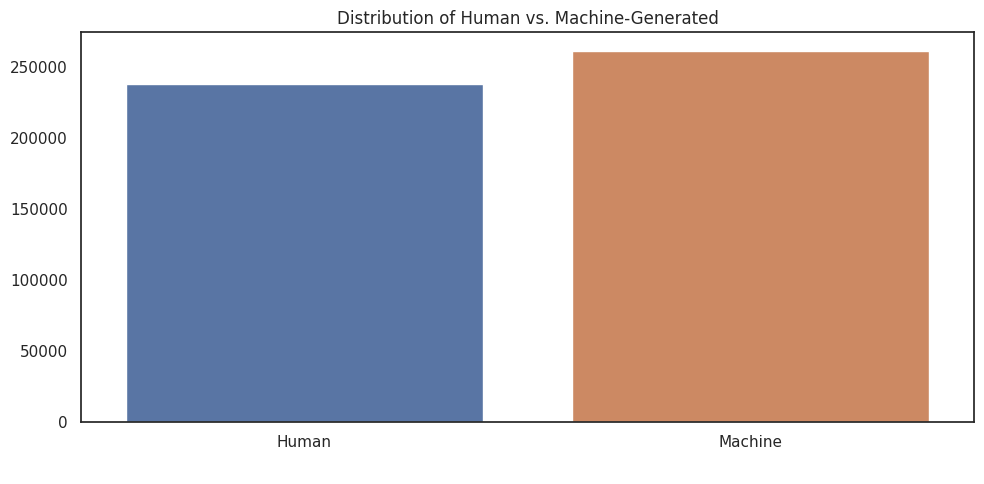

label
1    52.3
0    47.7
Name: count, dtype: float64

In [18]:
# Create folder if it doesn't exist
os.makedirs("plots", exist_ok=True)
# Set clean academic style
sns.set_style("white")
label_counts = train_data["label"].value_counts()
sns.barplot(
    x=label_counts.index,
    y=label_counts.values,
    hue=label_counts.index,
)
plt.title("Distribution of Human vs. Machine-Generated")
plt.xlabel(" ")
plt.xticks([0, 1], ["Human", "Machine"])


# Tight layout
plt.tight_layout()
# Remove legend if it exists
plt.legend([], [], frameon=False)


# Save figure as PDF
plt.savefig(
    "plots/label_distribution_human_vs_machine.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# percentage of Machine and Human generated code
(label_counts / len(train_data) * 100).round(2)

## Generator Frequency (for machine label)


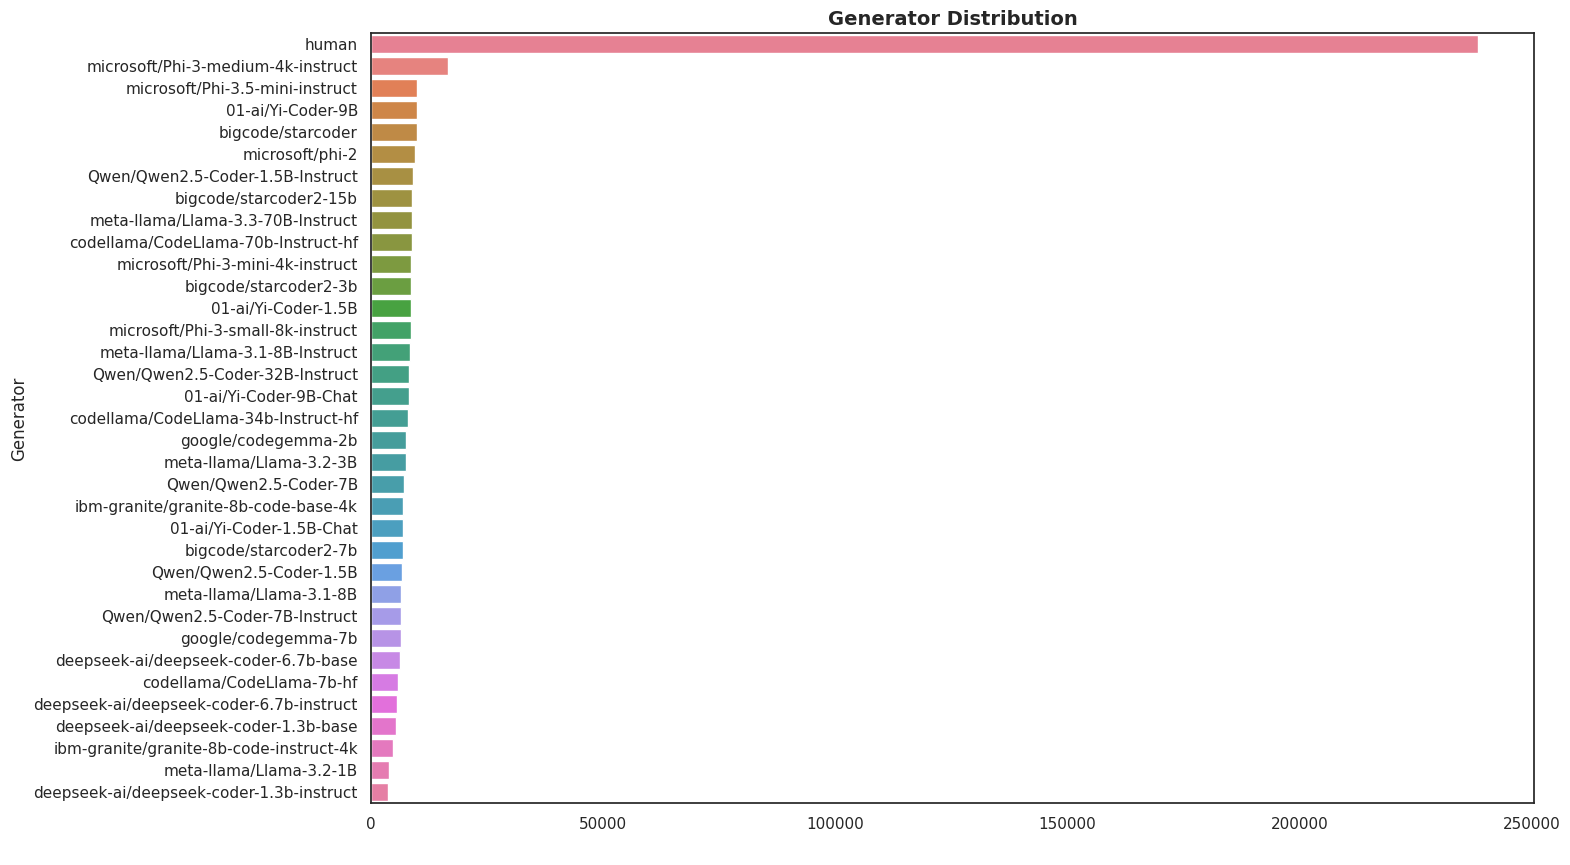

In [19]:
# Generator Distribution
plt.figure(figsize=(15, 10))
top_gen = train_data["generator"].value_counts()
sns.barplot(y=top_gen.index, x=top_gen.values, hue=top_gen.index)
plt.title("Generator Distribution", fontsize=14, weight="bold")
plt.xlabel(" ")
plt.ylabel("Generator")
# Save figure as PDF
plt.savefig("plots/generator_distribution.pdf", bbox_inches="tight")

plt.show()

## Distribution by Programming Language


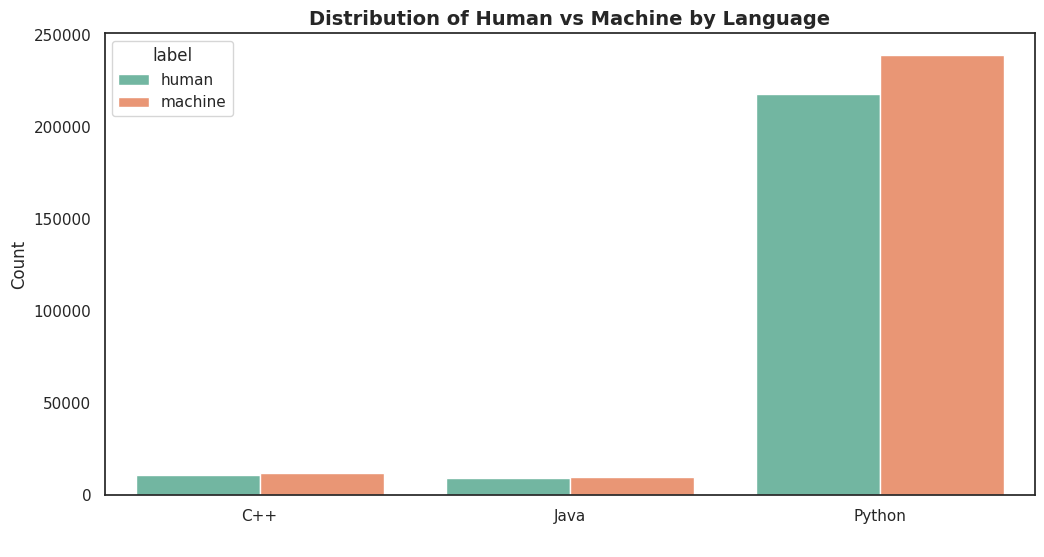

In [20]:
# Crosstab (language × label)
ct = pd.crosstab(train_data["language"], train_data["label"])

# Reset index so Seaborn can use it
ct = ct.reset_index()

# Melt into long format for seaborn
ct_melted = ct.melt(id_vars="language", var_name="label", value_name="count")

# Optional: rename labels only for the plot
ct_melted["label"] = ct_melted["label"].map({0: "human", 1: "machine"})

plt.figure(figsize=(12, 6))
sns.barplot(data=ct_melted, x="language", y="count", hue="label", palette="Set2")


plt.title("Distribution of Human vs Machine by Language", fontsize=14, weight="bold")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xlabel(" ")
plt.savefig("plots/programming_language_distribution.pdf", bbox_inches="tight")
plt.show()


# need new diagram for each language python what human has write and machine has write for each language

## Compute Characters count for each code snippet

Code length statistics
This helps see whether AI-generated code tends to be longer/shorter.


Min code Characters length: 0
Max code Characters length: 475006


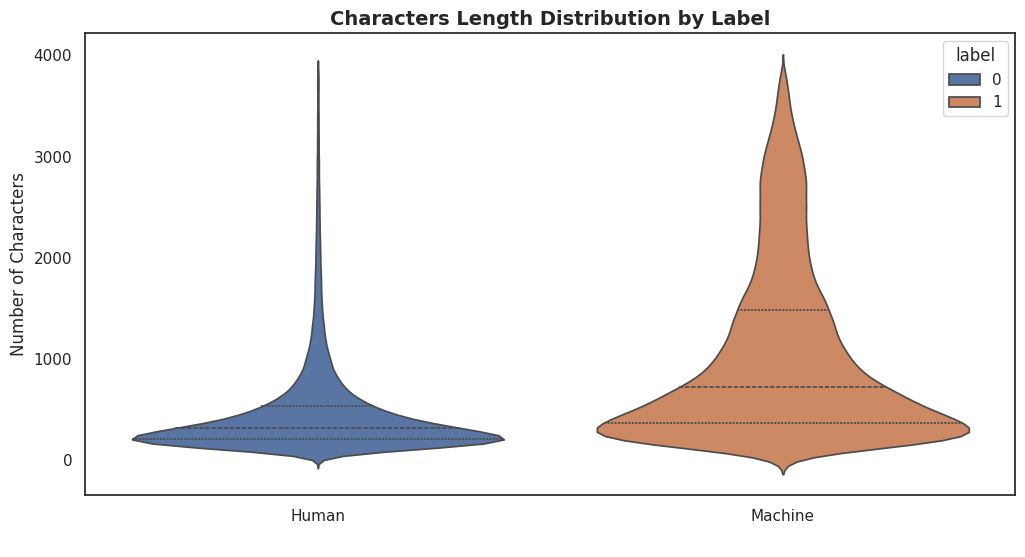

In [21]:
# Compute character length if not already done
train_data["code_length"] = train_data["code"].astype(str).str.len()
filtered = train_data[
    train_data["code_length"] < train_data["code_length"].quantile(0.99)
]

print("Min code Characters length:", train_data["code_length"].min())
print("Max code Characters length:", train_data["code_length"].max())

plt.figure(figsize=(12, 6))
sns.violinplot(x="label", y="code_length", data=filtered, inner="quartile", hue="label")
plt.xticks([0, 1], ["Human", "Machine"])
plt.title("Characters Length Distribution by Label", fontsize=14, weight="bold")
plt.ylabel("Number of Characters", fontsize=12)
plt.xlabel(" ")
plt.savefig("plots/character_length_distribution.pdf", bbox_inches="tight")
plt.show()

In [22]:
# train_data["code_length"] = train_data["code"].astype(str).str.len()
print(train_data["code_length"].describe())

count    500000.000000
mean        836.865392
std        1372.762958
min           0.000000
25%         255.000000
50%         464.000000
75%        1011.000000
max      475006.000000
Name: code_length, dtype: float64


## camelCase vs snake_case usage between human and machine-generated code


In [23]:
import re

camel_case_pattern = (
    r"\b[a-z]+(?:[A-Z][a-z0-9]+)+\b"  # e.g. myVariable, totalScoreValue
)
snake_case_pattern = r"\b[a-z]+(?:_[a-z0-9]+)+\b"  # e.g. my_variable, total_score


def count_camel_case(text):
    return len(re.findall(camel_case_pattern, text))


def count_snake_case(text):
    return len(re.findall(snake_case_pattern, text))


train_data["camel_count"] = train_data["code"].astype(str).apply(count_camel_case)
train_data["snake_count"] = train_data["code"].astype(str).apply(count_snake_case)

train_data["total_idents"] = train_data["camel_count"] + train_data["snake_count"]
train_data["camel_ratio"] = train_data["camel_count"] / (
    train_data["total_idents"] + 1e-5
)
train_data["snake_ratio"] = train_data["snake_count"] / (
    train_data["total_idents"] + 1e-5
)

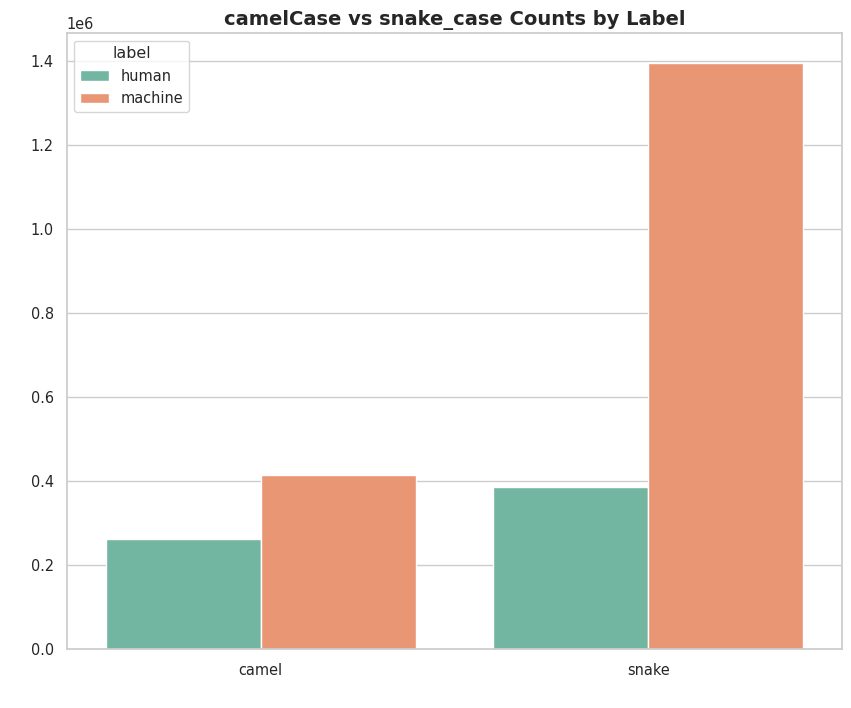

In [ ]:
# Sum camel and snake counts per label (human vs model)
summary = train_data.groupby("label")[["camel_count", "snake_count"]].sum()


# Convert to long format for seaborn
summary = summary.reset_index().melt(
    id_vars="label",
    value_vars=["camel_count", "snake_count"],
    var_name="case_type",
    value_name="count",
)

# Clean case_type names
summary["case_type"] = summary["case_type"].str.replace("_count", "")

summary["label"] = summary["label"].map({0: "human", 1: "machine"})

plt.figure(figsize=(10, 8))
sns.barplot(data=summary, x="case_type", y="count", hue="label", palette="Set2")

plt.title("camelCase vs snake_case Counts by Label", fontsize=14, weight="bold")
plt.ylabel(" ")
plt.xlabel(" ")
# Save figure as PDF
plt.savefig("plots/camelCase_vs_snake_case.pdf", bbox_inches="tight")
plt.show()

<Figure size 450x350 with 0 Axes>

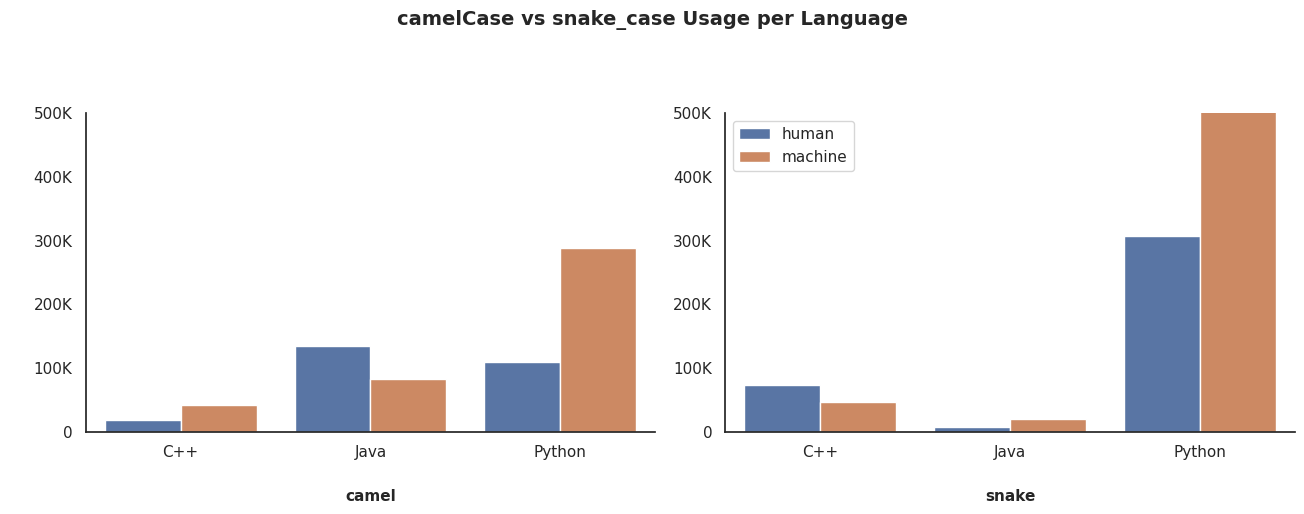

In [25]:
# --- Prepare the data ---
case_summary = (
    train_data.groupby(["language", "label"])[["camel_count", "snake_count"]]
    .sum()
    .reset_index()
)

# Convert wide → long format
case_summary = case_summary.melt(
    id_vars=["language", "label"],
    value_vars=["camel_count", "snake_count"],
    var_name="case_type",
    value_name="count",
)

# Clean names
case_summary["case_type"] = case_summary["case_type"].str.replace("_count", "")
case_summary["label"] = case_summary["label"].map({0: "human", 1: "machine"})

# --- Plot ---

plt.figure(figsize=(4.5, 3.5))
# Create separate bars (camelCase vs snake_case) using facet
g = sns.catplot(
    data=case_summary,
    x="language",
    y="count",
    hue="label",
    col="case_type",
    kind="bar",
    height=5,
    aspect=1.2,
    # palette="Set2",
    errorbar=None,
    sharey=False,
)

# ---------------------------------------
# Format Y-axis ticks (50K, 100K, etc.) and limit
# ---------------------------------------
import matplotlib.ticker as ticker


def thousands_formatter(x, pos):
    if x == 0:
        return "0"
    return f"{int(x/1000)}K"


for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(thousands_formatter))
    ax.set_ylim(0, 500_000)  # Limit y-axis to 600k


# Remove the default legend
g._legend.remove()

# # Add a single customized legend
# g.add_legend(
#     title=False,
#     bbox_to_anchor=(0.7, 0.9),
#     loc='upper center',
#     frameon=True,
#     fontsize=7,
#     title_fontsize=8
# )

g.set_titles(" ")
g.set_axis_labels(" ", " ")
# Add titles below each subplot
case_types = case_summary["case_type"].unique()

for ax, label in zip(g.axes.flat, case_types):
    ax.text(
        0.5,
        -0.18,  # x=center, y=below axis
        label,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=11,
        weight="bold",
    )
g.fig.suptitle(
    "camelCase vs snake_case Usage per Language", y=1.05, fontsize=14, weight="bold"
)
plt.xticks()
sns.despine()
plt.tight_layout()
# Save PDF
plt.legend(loc="upper left")
plt.savefig(
    "plots/case_usage_per_language.pdf", format="pdf", dpi=300, bbox_inches="tight"
)
plt.show()

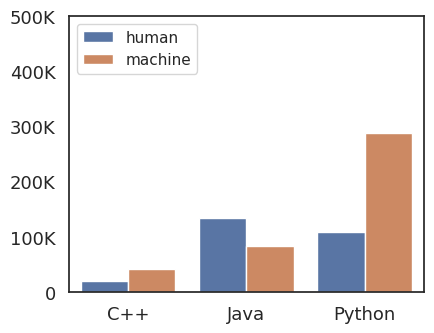

In [26]:
import matplotlib.ticker as ticker

# Filter camel only
camel_data = case_summary[case_summary["case_type"] == "camel"]

plt.figure(figsize=(4.5, 3.5))

ax = sns.barplot(data=camel_data, x="language", y="count", hue="label", errorbar=None)


# Format Y-axis
def thousands_formatter(x, pos):
    if x == 0:
        return "0"
    return f"{int(x/1000)}K"


ax.yaxis.set_major_formatter(ticker.FuncFormatter(thousands_formatter))
ax.set_ylim(0, 500_000)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)

plt.xlabel("")
plt.ylabel("")

plt.legend(title="", loc="upper left")
plt.tight_layout()
plt.savefig("plots/camel_usage_per_language.pdf", format="pdf", dpi=300)
plt.show()

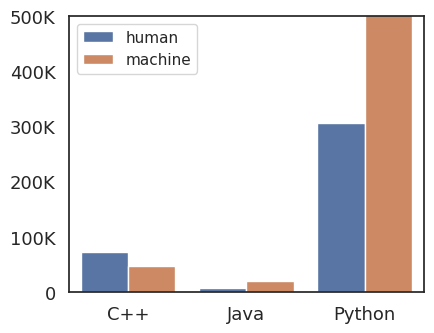

In [27]:
# Filter snake only
snake_data = case_summary[case_summary["case_type"] == "snake"]

plt.figure(figsize=(4.5, 3.5))

ax = sns.barplot(data=snake_data, x="language", y="count", hue="label", errorbar=None)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(thousands_formatter))
ax.set_ylim(0, 500_000)
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=13)

# plt.title("snake_case Usage per Language", fontsize=12, weight="bold")
plt.xlabel("")
plt.ylabel("")

plt.legend(title="", loc="upper left")
plt.tight_layout()
plt.savefig("plots/snake_usage_per_language.pdf", format="pdf", dpi=300)
plt.show()

In [ ]:
# ====================================================
# LOOP FEATURES
# ====================================================

# Matches: for, while (Python/JS/Java/C/C#/Go/PHP)
# Also catches: foreach, for...in, for...of
for_pattern = r"\bfor\b"
while_pattern = r"\bwhile\b"
foreach_pattern = r"\bforeach\b"  # PHP / C# / Java enhanced for


def count_total_loops(text):
    return (
        len(re.findall(for_pattern, text))
        + len(re.findall(while_pattern, text))
        + len(re.findall(foreach_pattern, text))
    )


train_data["num_while"] = train_data["code"].str.count(while_pattern)
train_data["num_for"] = train_data["code"].str.count(for_pattern)
train_data["num_foreach"] = train_data["code"].str.count(foreach_pattern)
train_data["total_loops"] = train_data["code"].apply(count_total_loops)
train_data["num_lines"] = train_data["code"].astype(str).str.count("\n") + 1

# loop density = loops per line of code
train_data["loop_density"] = train_data["total_loops"] / (
    train_data["num_lines"] + 1e-5
)


# ratio: how much is for vs while
train_data["for_while_ratio"] = train_data["num_for"] / (train_data["num_while"] + 1e-5)


# ====================================================
# NESTED LOOP FEATURES
# ====================================================


def count_nested_loops(code):
    """
    Count loop keywords that appear inside an indented block
    that already contains a loop keyword.
    Works for Python (indent-based) and brace languages.
    Strategy: scan line-by-line, track indent depth of outer loops.
    """
    lines = code.split("\n")
    loop_kws = re.compile(r"\b(for|while|foreach)\b")

    nested = 0
    depths = []  # indent depths of active outer loops

    for line in lines:
        stripped = line.lstrip()
        indent = len(line) - len(stripped)

        # close loops that are no longer in scope (un-indented past)
        depths = [d for d in depths if d < indent]

        if loop_kws.search(stripped):
            if depths:  # there is an outer loop still open
                nested += 1
            depths.append(indent)

    return nested


def max_nesting_depth(code):
    """
    Measure how deep the deepest nested loop goes (0 = no loops at all).
    """
    lines = code.split("\n")
    loop_kws = re.compile(r"\b(for|while|foreach)\b")
    depths = []
    max_d = 0

    for line in lines:
        stripped = line.lstrip()
        indent = len(line) - len(stripped)
        depths = [d for d in depths if d < indent]

        if loop_kws.search(stripped):
            current_depth = len(depths) + 1
            max_d = max(max_d, current_depth)
            depths.append(indent)

    return max_d


train_data["num_nested_loops"] = train_data["code"].apply(count_nested_loops)
train_data["max_nesting_depth"] = train_data["code"].apply(max_nesting_depth)

train_data["nested_loop_ratio"] = train_data["num_nested_loops"] / (
    train_data["total_loops"] + 1e-5
)

# average nesting depth approximation
train_data["avg_nesting_depth"] = train_data["num_nested_loops"] / (
    train_data["total_loops"] + 1e-5
)


# ====================================================
# COMMENT FEATURES  (multi-language)
# ====================================================

single_line_comment = r"(#|//)"  # Python, JS, C, Java, Go
block_comment_open = r"/\*"  # C, C++, Java, JS, C#, Go
block_comment_close = r"\*/"
docstring_pattern = r"(\"\"\"[\s\S]*?\"\"\"|\'\'\'[\s\S]*?\'\'\')"  # Python


def count_inline_comments(code):
    """Comments that appear on the same line as code."""
    count = 0
    for line in code.split("\n"):
        stripped = line.strip()
        # has code AND a comment marker (not a pure comment line)
        if (
            re.search(single_line_comment, stripped)
            and not stripped.startswith("#")
            and not stripped.startswith("//")
        ):
            count += 1
    return count


def count_block_comments(code):
    return len(re.findall(block_comment_open, code))


def count_docstrings(code):
    return len(re.findall(docstring_pattern, code))


train_data["num_single_comments"] = train_data["code"].str.count(single_line_comment)
train_data["num_block_comments"] = train_data["code"].apply(count_block_comments)
train_data["num_docstrings"] = train_data["code"].apply(count_docstrings)
train_data["num_inline_comments"] = train_data["code"].apply(count_inline_comments)

# comment density = comment lines / total lines
train_data["comment_density"] = train_data["num_single_comments"] / (
    train_data["num_lines"] + 1e-5
)

# ratio of code lines to comment lines
train_data["code_to_comment_ratio"] = (
    train_data["num_lines"] - train_data["num_single_comments"]
) / (train_data["num_single_comments"] + 1e-5)

In [30]:
# ====================================================
# EXCEPTION HANDLING FEATURES  (multi-language)
# ====================================================

try_pattern = r"\btry\b"
except_pattern = r"\b(except|catch)\b"  # Python: except | Java/JS/C#: catch
finally_pattern = r"\bfinally\b"
throw_pattern = r"\b(raise|throw)\b"  # Python: raise | others: throw

train_data["num_try"] = train_data["code"].str.count(try_pattern)
train_data["num_except"] = train_data["code"].str.count(except_pattern)
train_data["num_finally"] = train_data["code"].str.count(finally_pattern)
train_data["num_throw"] = train_data["code"].str.count(throw_pattern)

# how well guarded is the code?
train_data["try_except_ratio"] = train_data["num_try"] / (
    train_data["num_except"] + 1e-5
)

# error handling density = try blocks per line
train_data["error_handling_density"] = train_data["num_try"] / (
    train_data["num_lines"] + 1e-5
)

# does it use bare excepts / catches (bad practice signal)?
train_data["has_bare_except"] = (
    train_data["code"].str.contains(r"\bexcept\s*:", regex=True).astype(int)
)


# ====================================================
# FUNCTION / CLASS FEATURES  (multi-language)
# ====================================================

# Python: def / class
# Java/C#/Go: return type + name + ( ... ) — approximated by counting {
# JS: function keyword or arrow =>
# C/C++: same as JS function count

def_pattern = r"\bdef\b"  # Python
function_pattern = r"\bfunction\b"  # JS / PHP
arrow_pattern = r"=>"  # JS arrow functions
class_pattern = r"\bclass\b"
lambda_pattern = r"\blambda\b"  # Python

train_data["num_functions"] = train_data["code"].str.count(
    def_pattern
) + train_data[  # Python
    "code"
].str.count(
    function_pattern
)  # JS/PHP
train_data["num_arrow_funcs"] = train_data["code"].str.count(arrow_pattern)
train_data["num_classes"] = train_data["code"].str.count(class_pattern)
train_data["num_lambdas"] = train_data["code"].str.count(lambda_pattern)

# function density = functions per line
train_data["func_density"] = train_data["num_functions"] / (
    train_data["num_lines"] + 1e-5
)

# average estimated function length (rough: lines / num_functions)
train_data["avg_func_length"] = train_data["num_lines"] / (
    train_data["num_functions"] + 1e-5
)

# class to function ratio (OOP vs procedural signal)
train_data["class_func_ratio"] = train_data["num_classes"] / (
    train_data["num_functions"] + 1e-5
)

In [ ]:
new_features = [
    "total_loops",
    "num_while",
    "loop_density",
    "for_while_ratio",
    "num_nested_loops",
    "max_nesting_depth",
    "nested_loop_ratio",
    "comment_density",
    "code_to_comment_ratio",
    "num_block_comments",
    "num_try",
    "num_except",
    "try_except_ratio",
    "error_handling_density",
    "num_functions",
    "num_classes",
    "func_density",
    "avg_func_length",
]

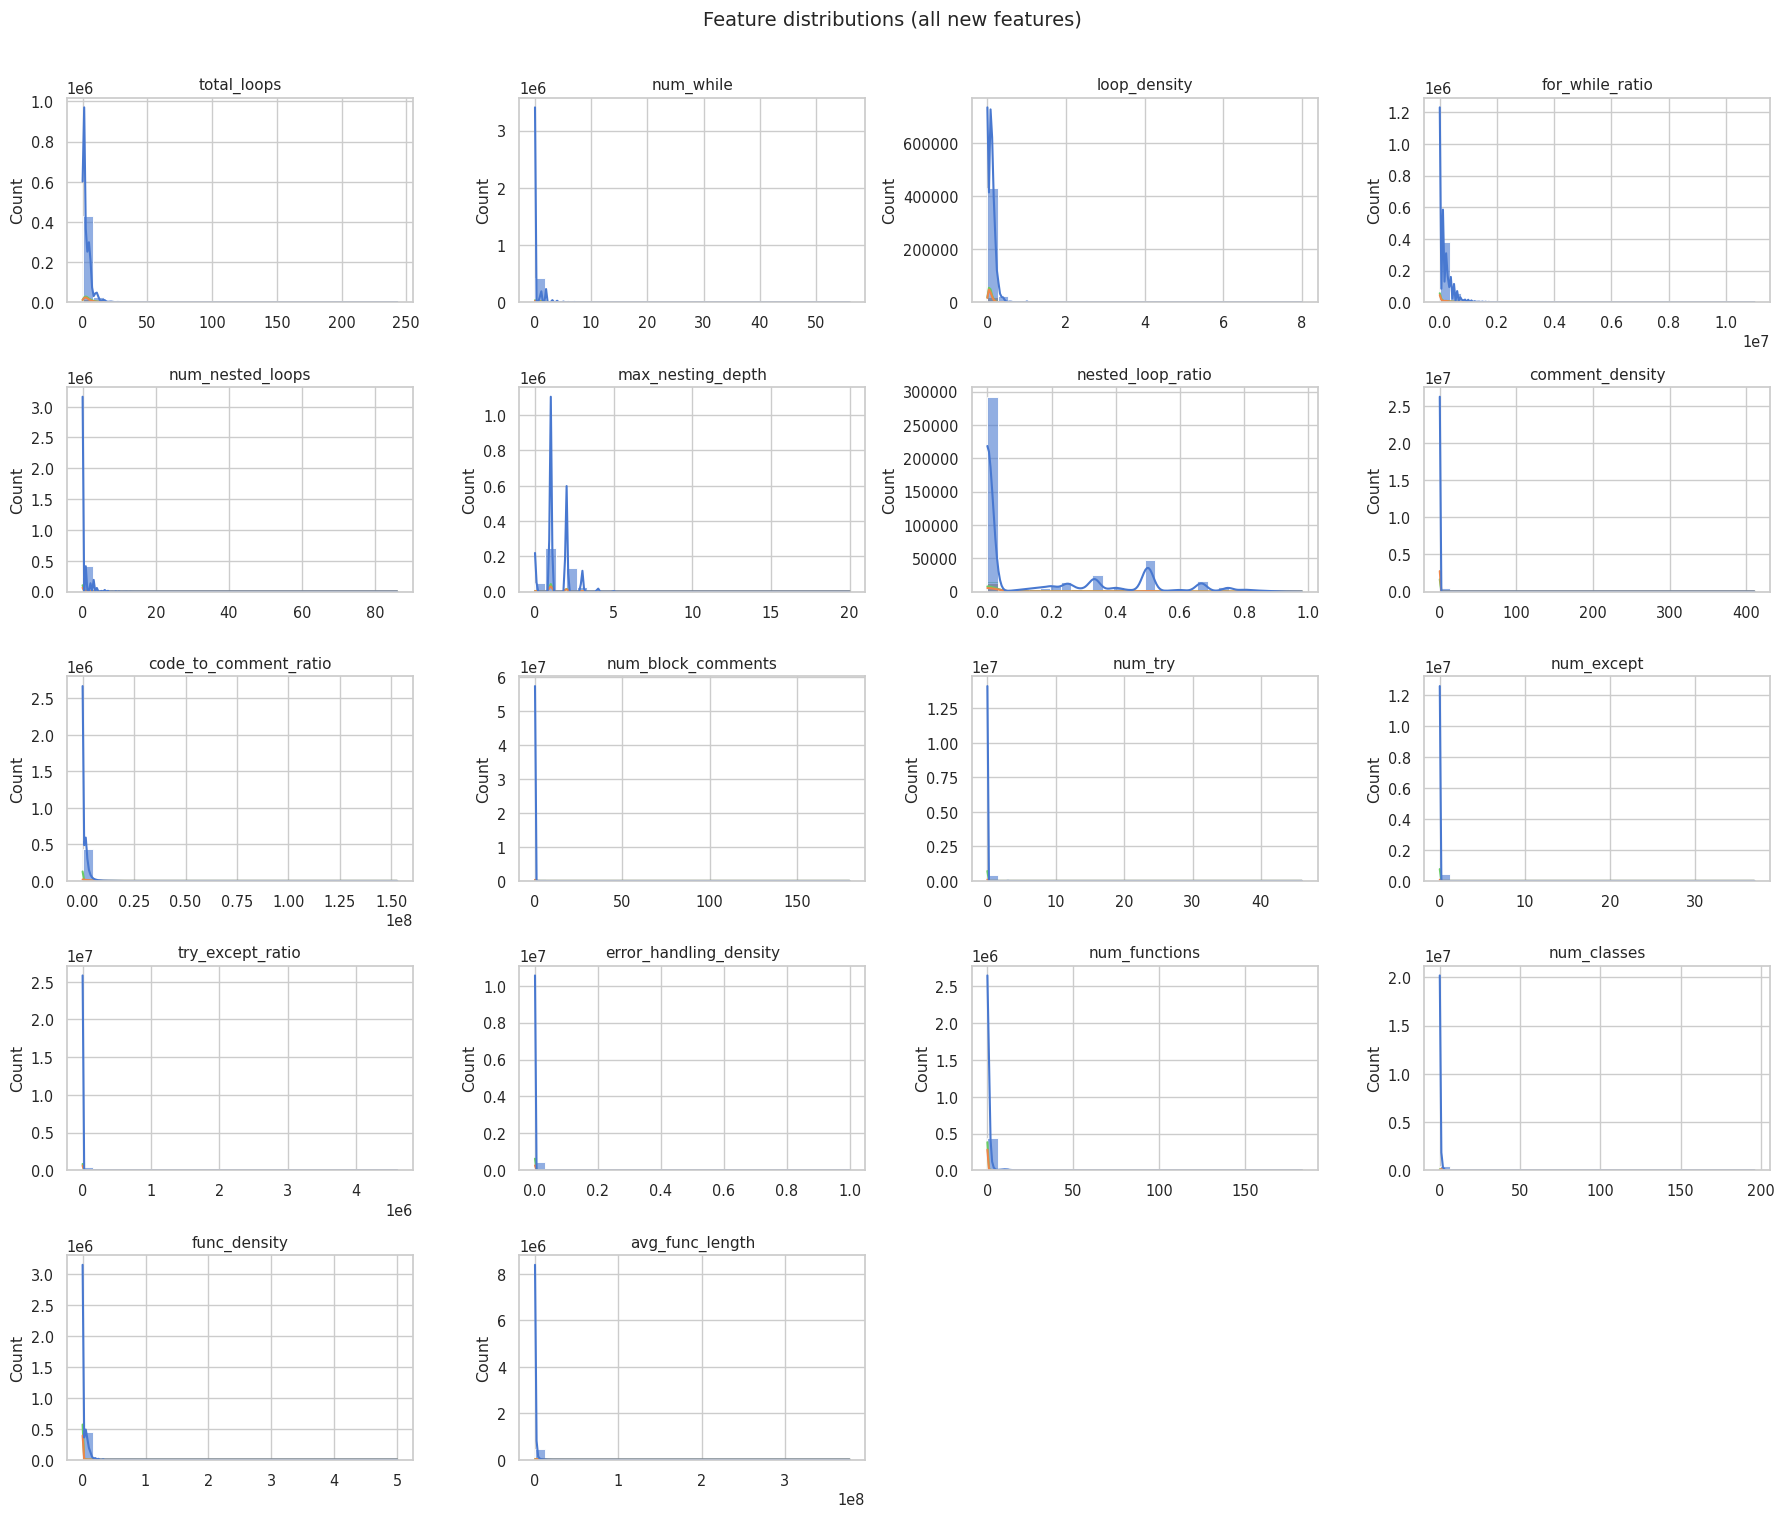

In [ ]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.95)
LANG_COL = "language"  # change if your column is named differently


# ── helper ──────────────────────────────────────────────────────────────────
def safe_cols(df, cols):
    """Return only columns that actually exist in df."""
    return [c for c in cols if c in df.columns]


# ─────────────────────────────────────────────────────────────────────────────
# 1. DISTRIBUTION OVERVIEW  (histograms for every new feature)
# ─────────────────────────────────────────────────────────────────────────────

cols = safe_cols(train_data, new_features)

n_cols = 4
n_rows = int(np.ceil(len(cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(
        data=train_data,
        x=col,
        hue=LANG_COL if LANG_COL in train_data else None,
        bins=30,
        kde=True,
        ax=axes[i],
        legend=False,
        alpha=0.6,
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature distributions (all new features)", y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig("1_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


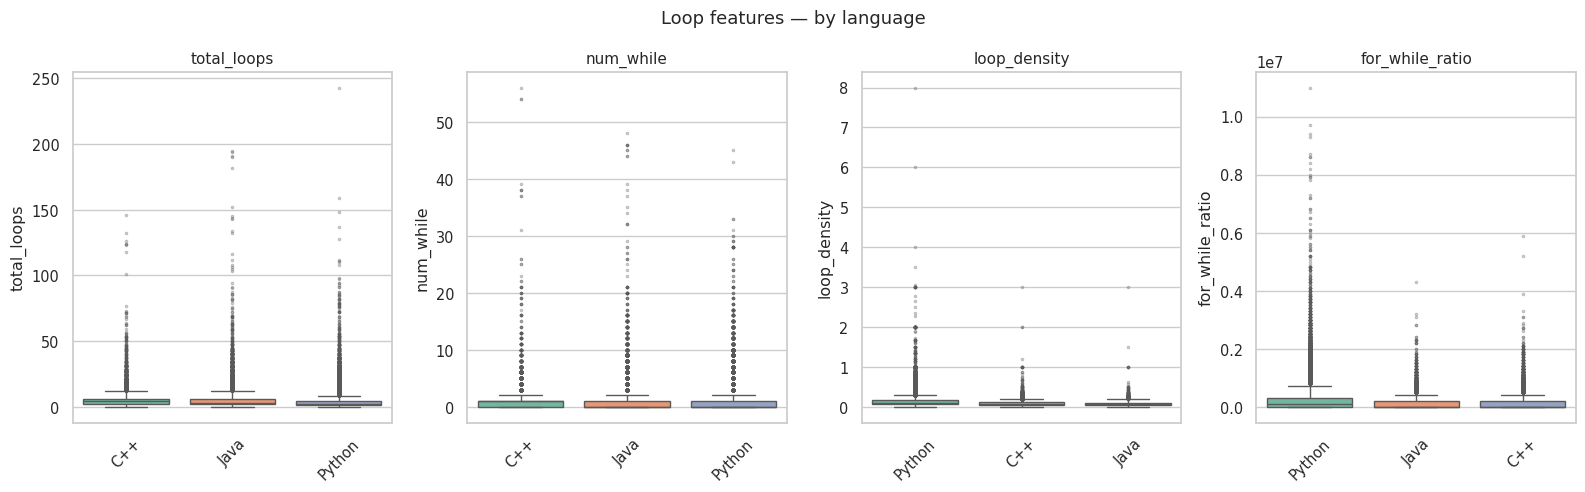

/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


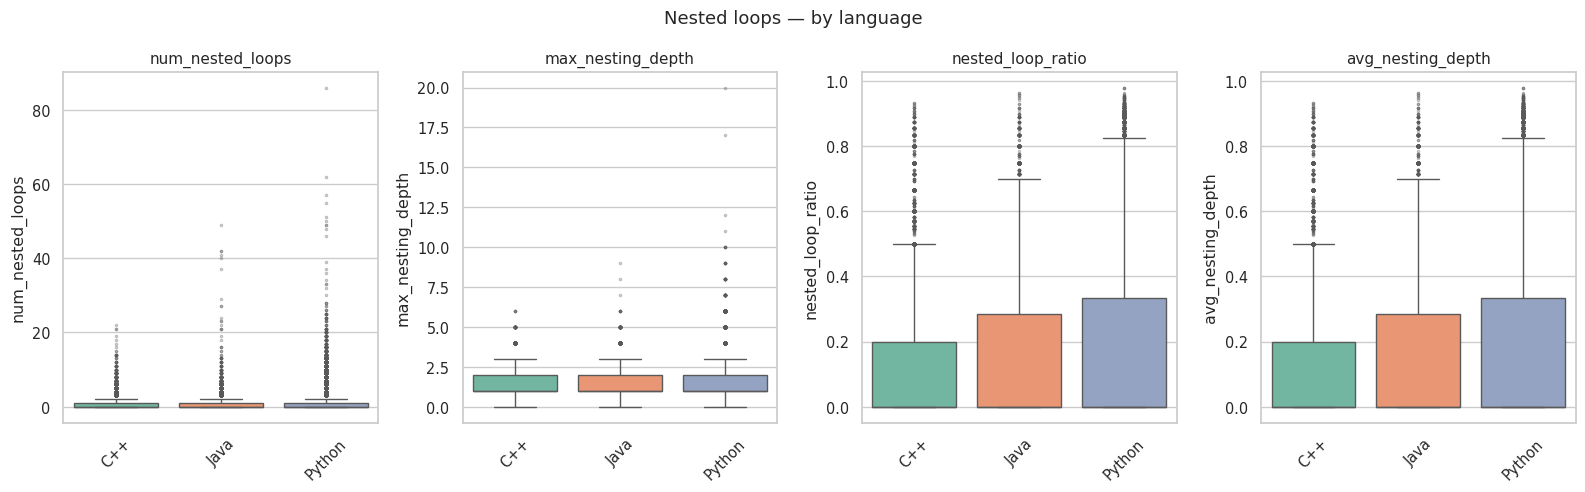

/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


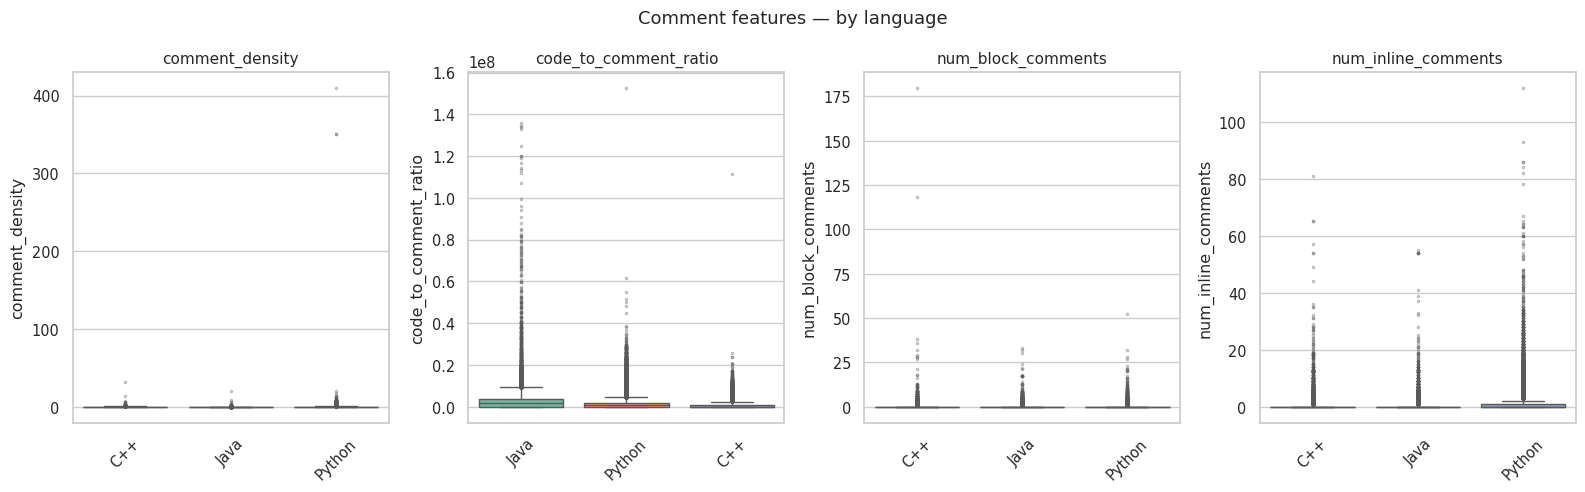

/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning

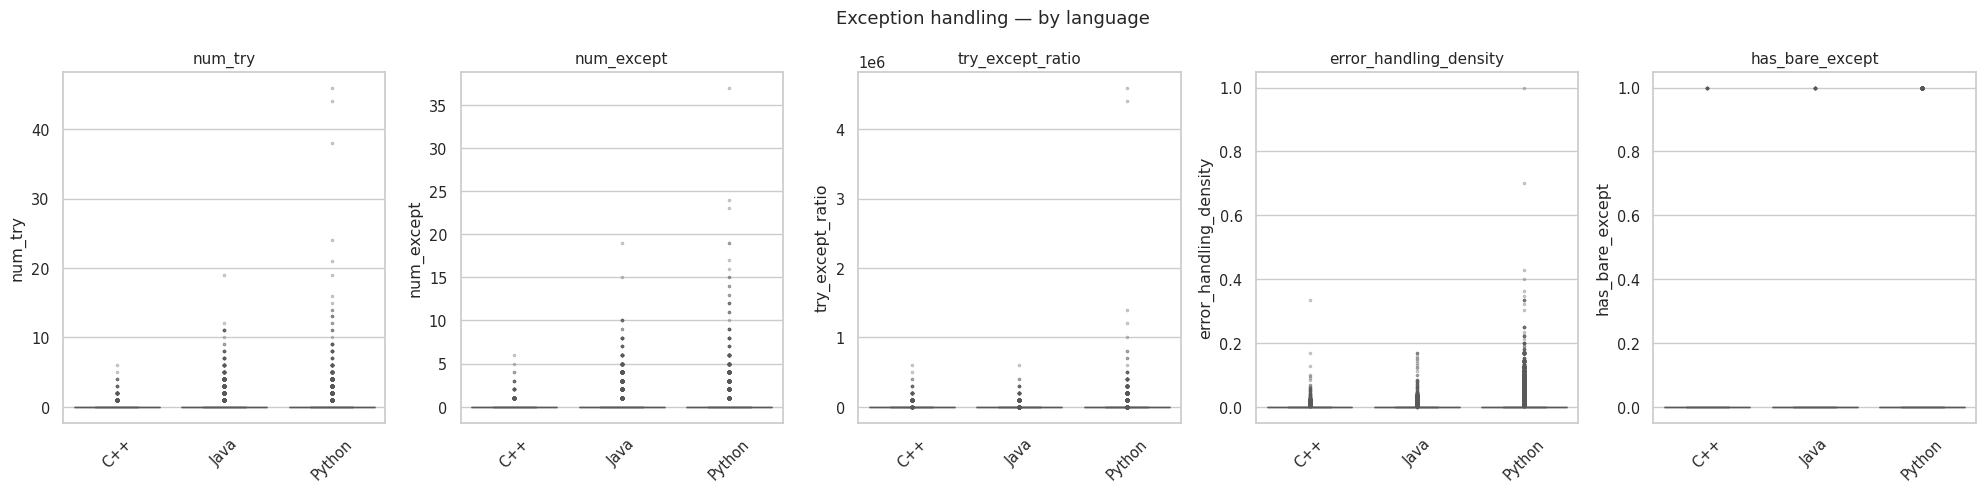

/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_227799/460324273.py:27: FutureWarning

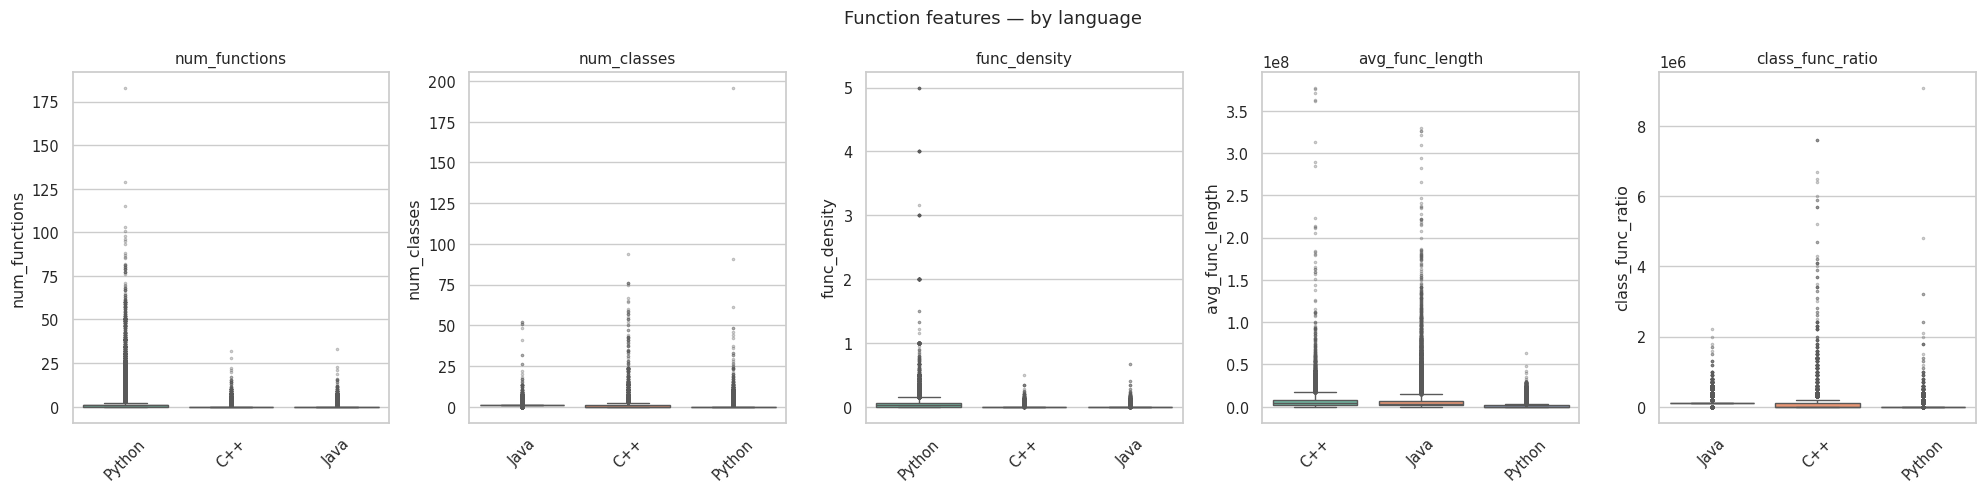

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. PER-LANGUAGE BOXPLOTS  (one grid per feature group)
# ─────────────────────────────────────────────────────────────────────────────
groups = {
    "Loop features": ["total_loops", "num_while", "loop_density", "for_while_ratio"],
    "Nested loops": [
        "num_nested_loops",
        "max_nesting_depth",
        "nested_loop_ratio",
        "avg_nesting_depth",
    ],
    "Comment features": [
        "comment_density",
        "code_to_comment_ratio",
        "num_block_comments",
        "num_inline_comments",
    ],
    "Exception handling": [
        "num_try",
        "num_except",
        "try_except_ratio",
        "error_handling_density",
        "has_bare_except",
    ],
    "Function features": [
        "num_functions",
        "num_classes",
        "func_density",
        "avg_func_length",
        "class_func_ratio",
    ],
}

for group_name, group_cols in groups.items():
    cols = safe_cols(train_data, group_cols)
    if not cols:
        continue

    fig, axes = plt.subplots(1, len(cols), figsize=(4 * len(cols), 5))
    if len(cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        order = (
            train_data.groupby(LANG_COL)[col]
            .median()
            .sort_values(ascending=False)
            .index
            if LANG_COL in train_data.columns
            else None
        )
        sns.boxplot(
            data=train_data,
            x=LANG_COL,
            y=col,
            order=order,
            palette="Set2",
            ax=ax,
            flierprops={"marker": ".", "markersize": 3, "alpha": 0.4},
        )
        ax.set_title(col, fontsize=11)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45)

    plt.suptitle(f"{group_name} — by language", fontsize=13)
    plt.tight_layout()
    fname = group_name.lower().replace(" ", "_")
    plt.savefig(f"2_{fname}_boxplot.png", dpi=150, bbox_inches="tight")
    plt.show()

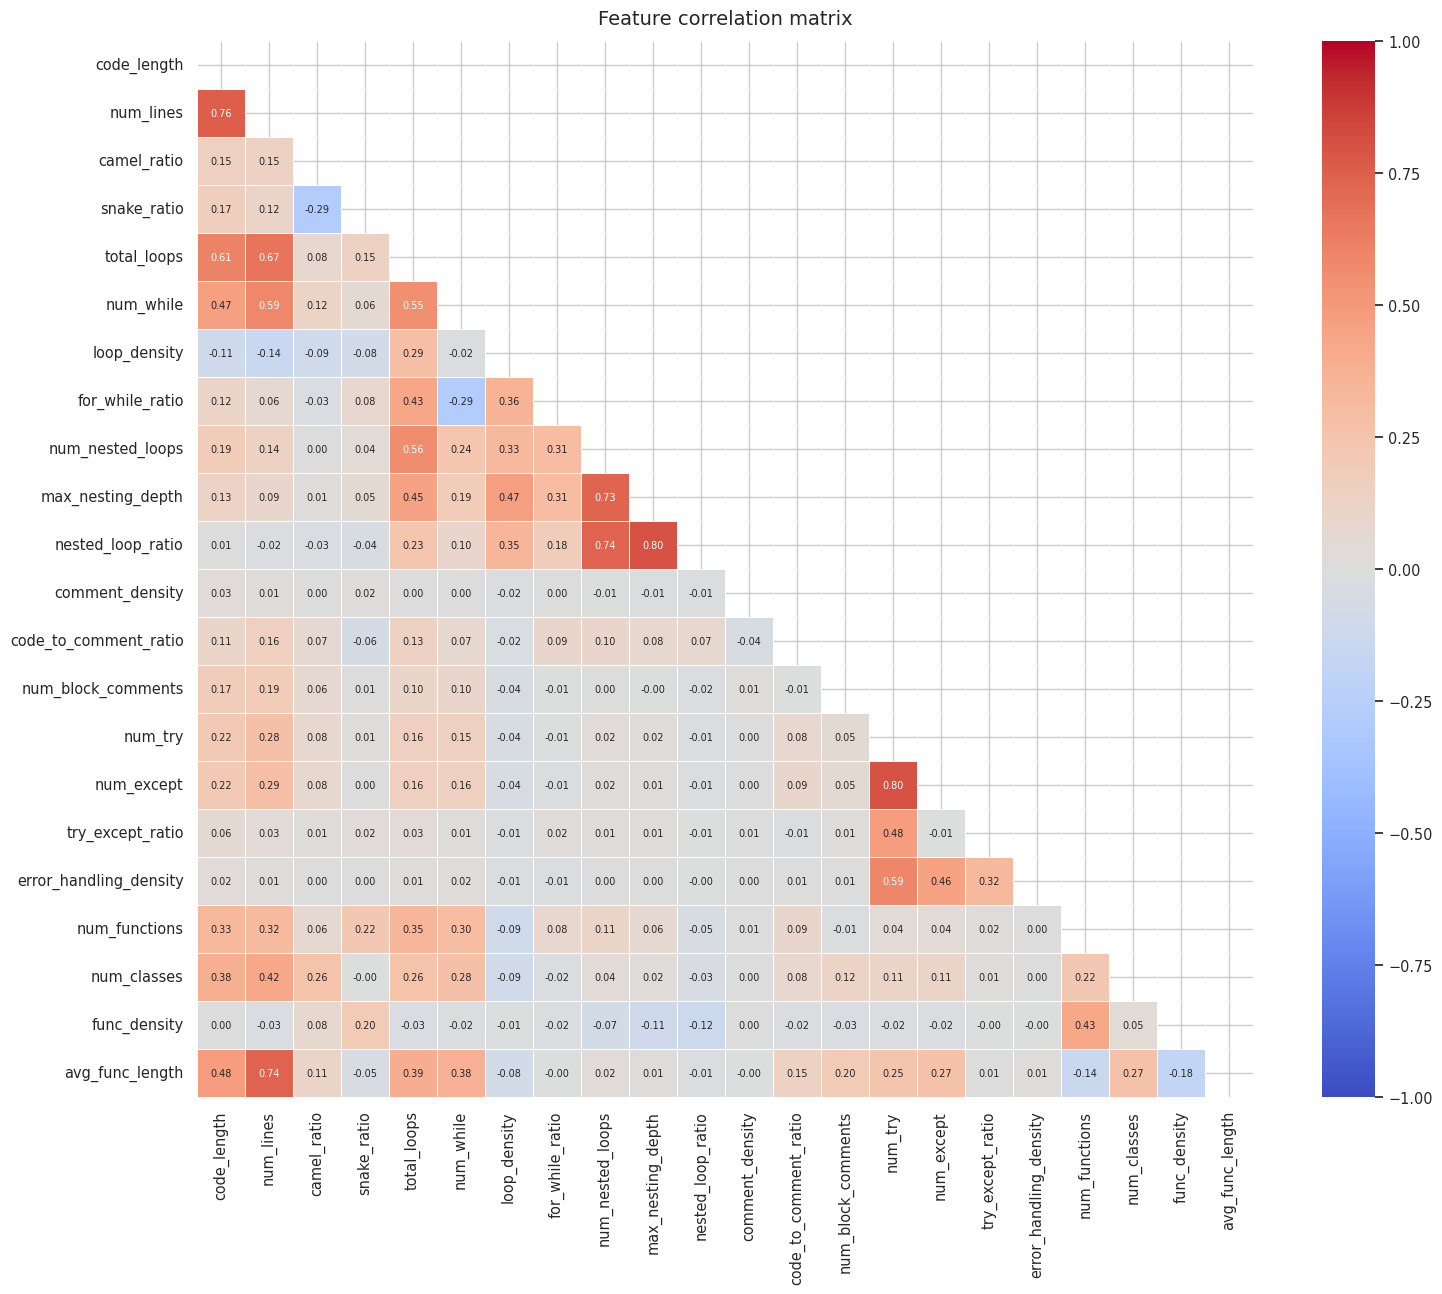

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. CORRELATION HEATMAP  (all new features + existing ones)
# ─────────────────────────────────────────────────────────────────────────────
all_numeric = safe_cols(
    train_data,
    [
        "code_length",
        "num_lines",
        "num_comments",
        "camel_ratio",
        "snake_ratio",
        *new_features,
    ],
)
corr = train_data[all_numeric].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle → blank
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    annot_kws={"size": 7},
    ax=ax,
    vmin=-1,
    vmax=1,
    square=True,
)
ax.set_title("Feature correlation matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("3_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_227799/642671295.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_227799/642671295.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_227799/642671295.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_227799/642671295.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_227799/642671295.py:18: F

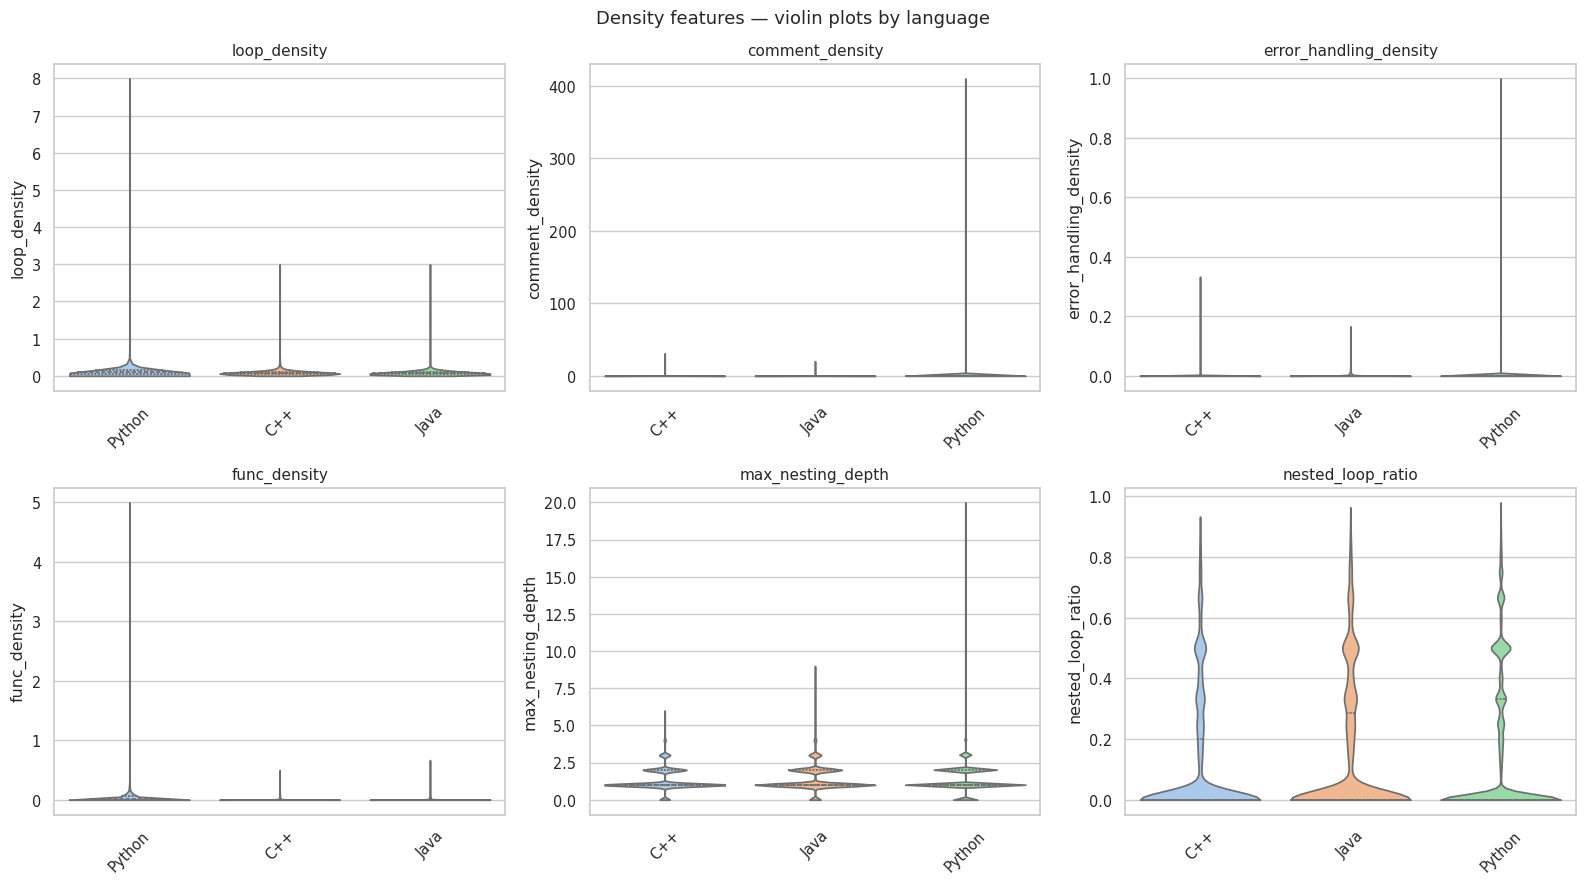

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. VIOLIN PLOTS  — richer than boxplots for multimodal distributions
# ─────────────────────────────────────────────────────────────────────────────
violin_features = safe_cols(
    train_data,
    [
        "loop_density",
        "comment_density",
        "error_handling_density",
        "func_density",
        "max_nesting_depth",
        "nested_loop_ratio",
    ],
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(violin_features):
    order = (
        train_data.groupby(LANG_COL)[col].median().sort_values(ascending=False).index
        if LANG_COL in train_data.columns
        else None
    )
    sns.violinplot(
        data=train_data,
        x=LANG_COL,
        y=col,
        order=order,
        palette="pastel",
        inner="quartile",
        cut=0,
        ax=axes[i],
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Density features — violin plots by language", fontsize=13)
plt.tight_layout()
plt.savefig("4_violin_density.png", dpi=150, bbox_inches="tight")
plt.show()

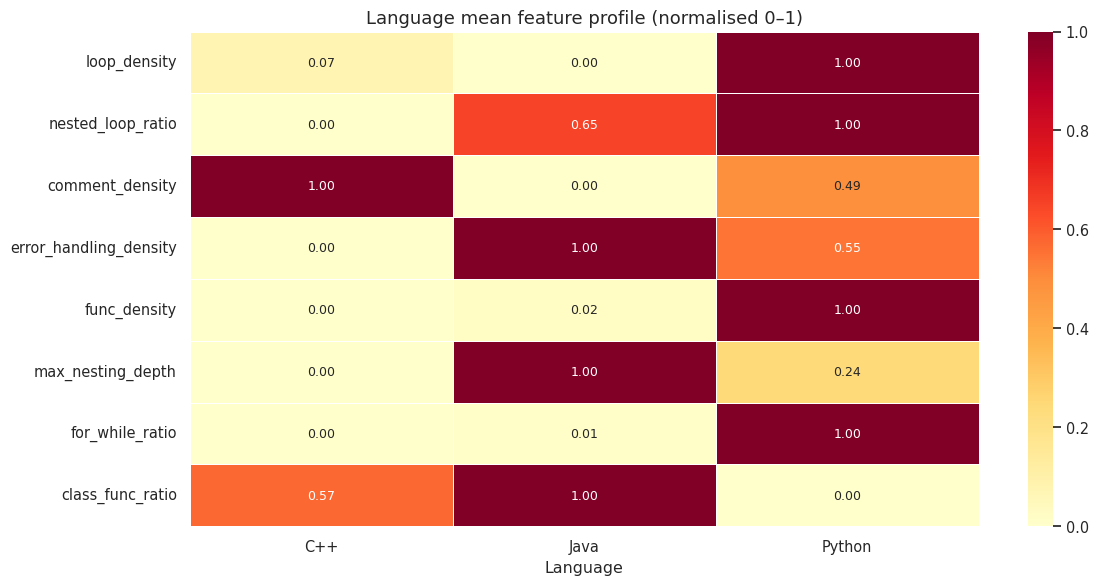

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. LANGUAGE MEAN PROFILE  (radar / heatmap style)
# ─────────────────────────────────────────────────────────────────────────────
profile_cols = safe_cols(
    train_data,
    [
        "loop_density",
        "nested_loop_ratio",
        "comment_density",
        "error_handling_density",
        "func_density",
        "max_nesting_depth",
        "for_while_ratio",
        "class_func_ratio",
    ],
)

if LANG_COL in train_data.columns and profile_cols:
    profile = (
        train_data.groupby(LANG_COL)[profile_cols]
        .mean()
        .apply(lambda c: (c - c.min()) / (c.max() - c.min() + 1e-9))  # 0–1 scale
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(
        profile.T,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        linewidths=0.4,
        annot_kws={"size": 9},
        ax=ax,
    )
    ax.set_title("Language mean feature profile (normalised 0–1)", fontsize=13)
    ax.set_xlabel("Language")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig("5_language_profile.png", dpi=150, bbox_inches="tight")
    plt.show()

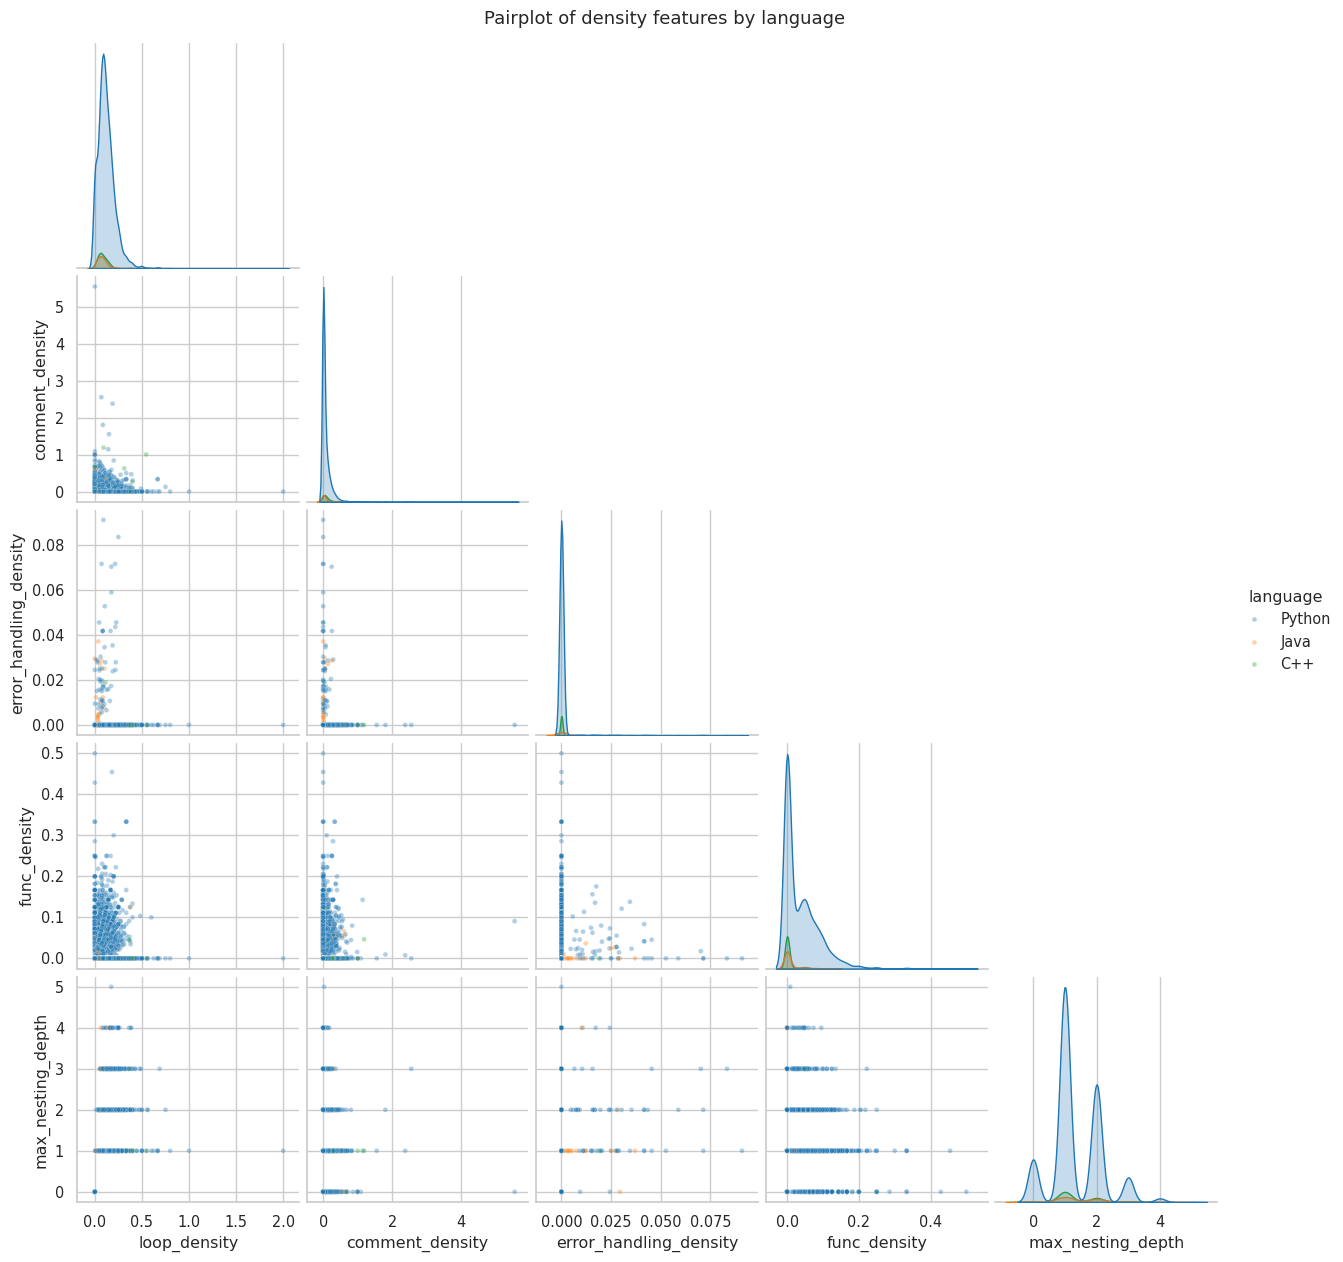

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. PAIRPLOT  — key density features coloured by language
# ─────────────────────────────────────────────────────────────────────────────
pair_cols = safe_cols(
    train_data,
    [
        "loop_density",
        "comment_density",
        "error_handling_density",
        "func_density",
        "max_nesting_depth",
    ],
)

if LANG_COL in train_data.columns and len(pair_cols) >= 2:
    sample = train_data.sample(min(3000, len(train_data)), random_state=42)
    g = sns.pairplot(
        sample[pair_cols + [LANG_COL]],
        hue=LANG_COL,
        corner=True,
        plot_kws={"alpha": 0.35, "s": 12},
        diag_kind="kde",
        palette="tab10",
    )
    g.figure.suptitle("Pairplot of density features by language", y=1.01, fontsize=13)
    plt.savefig("6_pairplot.png", dpi=130, bbox_inches="tight")
    plt.show()

<!-- ## Keyword / token analysis

Top tokens in human vs machine -->


In [ ]:
def get_token_frequencies(text_series, ngram_range=(1, 1), stop_words=None):
    vectorizer = CountVectorizer(stop_words=stop_words, ngram_range=ngram_range)
    bow = vectorizer.fit_transform(text_series)

    token_counts = np.array(bow.sum(axis=0)).flatten()
    tokens = vectorizer.get_feature_names_out()

    df = pd.DataFrame({"token": tokens, "frequency": token_counts}).sort_values(
        by="frequency", ascending=False
    )

    return df, vectorizer

In [ ]:
human_code = train_data[train_data["generator"] == "human"]["code"]
ai_code = train_data[train_data["generator"] != "human"]["code"]

human_freq_df, human_vec = get_token_frequencies(human_code)
ai_freq_df, ai_vec = get_token_frequencies(ai_code)

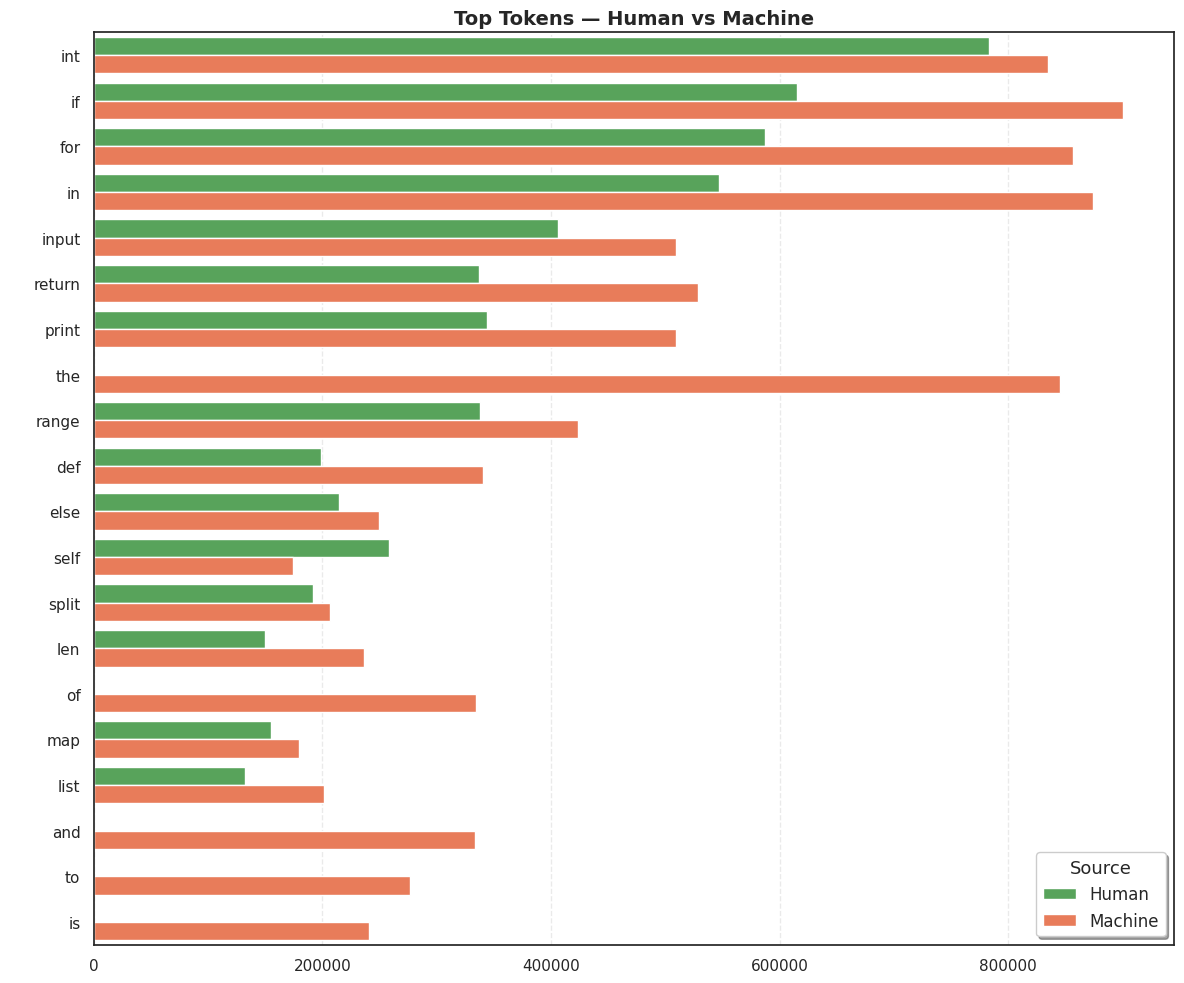

In [ ]:
# Select top tokens
TOP_N = 20

human_top = human_freq_df.head(TOP_N).rename(columns={"frequency": "human_freq"})
ai_top = ai_freq_df.head(TOP_N).rename(columns={"frequency": "machine_freq"})

# Merge (union of tokens)
merged = pd.merge(human_top, ai_top, on="token", how="outer").fillna(0)

# Add combined frequency to sort meaningfully
merged["total"] = merged["human_freq"] + merged["machine_freq"]
merged = merged.sort_values("total", ascending=False).head(TOP_N)

# Melt long format
plot_df = merged.melt(
    id_vars="token",
    value_vars=["human_freq", "machine_freq"],
    var_name="source",
    value_name="frequency",
)

plot_df["source"] = plot_df["source"].map(
    {"human_freq": "Human", "machine_freq": "Machine"}
)

# --- Beautiful Professional Plot ---
plt.figure(figsize=(12, 10))

sns.barplot(
    data=plot_df,
    y="token",
    x="frequency",
    hue="source",
    palette=["#4CAF50", "#FF7043"],  # professional colors
    dodge=True,
)

plt.title("Top Tokens — Human vs Machine", fontsize=14, weight="bold")
plt.xlabel("", fontsize=12)
plt.ylabel(" ", fontsize=12)

plt.legend(title="Source", fontsize=12, title_fontsize=13, frameon=True, shadow=True)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("plots/top_tokens_human_vs_machine.pdf", bbox_inches="tight")
plt.show()

## For any N-grams

- for N-grams (like for i, def func, etc.)
- human*freq_df, * = get_token_frequencies(human_code, ngram_range=(1,2))


In [140]:
# Compute bigram frequencies
human_bi_df, _ = get_token_frequencies(human_code, ngram_range=(2, 2))
machine_bi_df, _ = get_token_frequencies(ai_code, ngram_range=(2, 2))

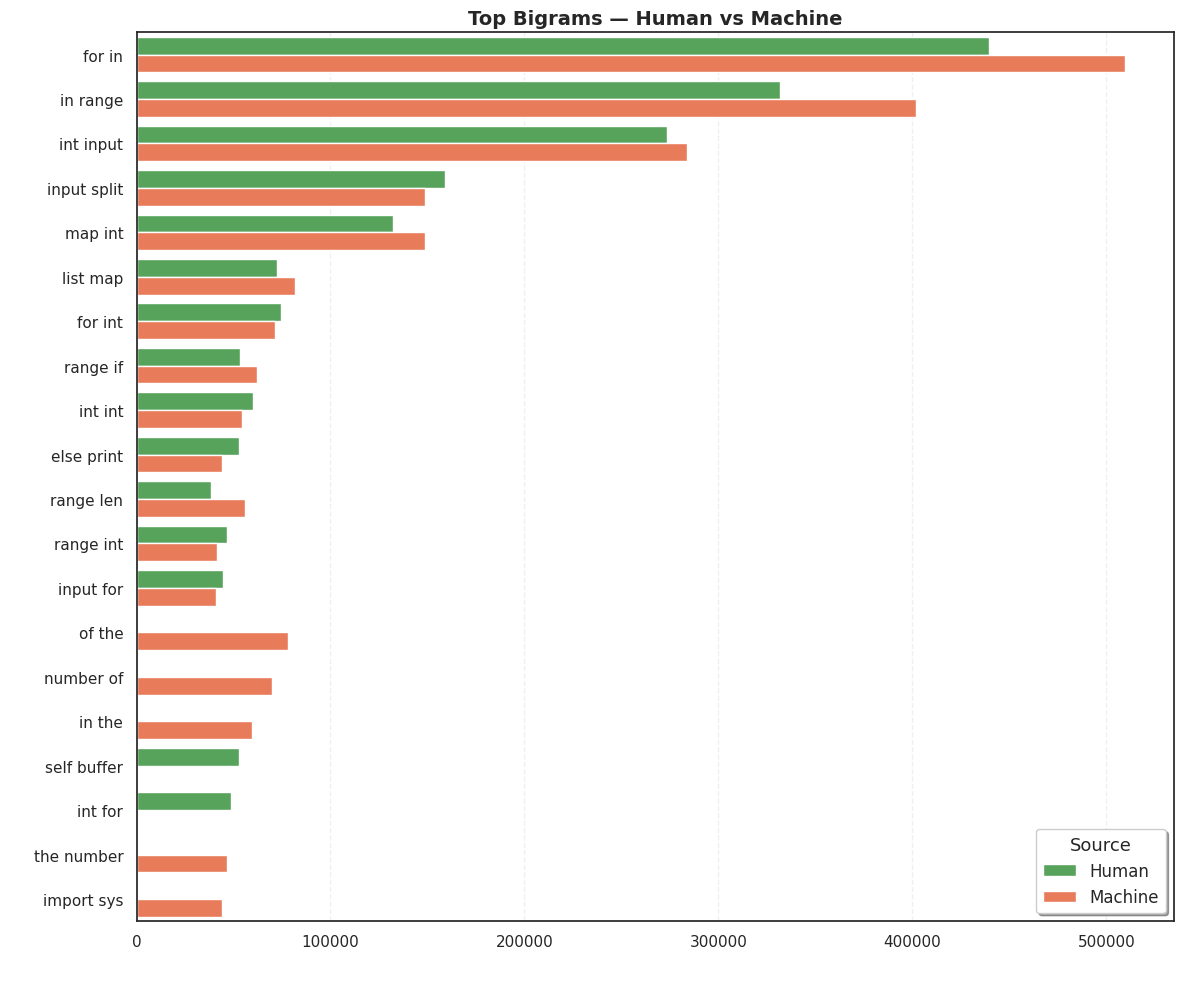

In [ ]:
TOP_N = 20  # adjust as needed (10, 20, 30)

# Select top N bigrams
human_top = human_bi_df.head(TOP_N).rename(columns={"frequency": "human_freq"})
machine_top = machine_bi_df.head(TOP_N).rename(columns={"frequency": "machine_freq"})

# Merge union of bigrams
merged = pd.merge(human_top, machine_top, on="token", how="outer").fillna(0)

# Combined importance for sorting
merged["total"] = merged["human_freq"] + merged["machine_freq"]
merged = merged.sort_values("total", ascending=False).head(TOP_N)

# Melt for plotting
plot_df = merged.melt(
    id_vars="token",
    value_vars=["human_freq", "machine_freq"],
    var_name="source",
    value_name="frequency",
)

plot_df["source"] = plot_df["source"].map(
    {"human_freq": "Human", "machine_freq": "Machine"}
)

# --- Professional Plot ---
plt.figure(figsize=(12, 10))
sns.barplot(
    data=plot_df,
    y="token",
    x="frequency",
    hue="source",
    palette=["#4CAF50", "#FF7043"],  # clean, high-contrast colors
    dodge=True,
)

plt.title("Top Bigrams — Human vs Machine", fontsize=14, weight="bold")
plt.xlabel(" ", fontsize=12)
plt.ylabel(" ", fontsize=12)

plt.legend(title="Source", fontsize=12, title_fontsize=13, frameon=True, shadow=True)

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()

plt.savefig("plots/top_bigrams_human_vs_machine.pdf", bbox_inches="tight")
plt.show()


=== Processing Language: Python ===


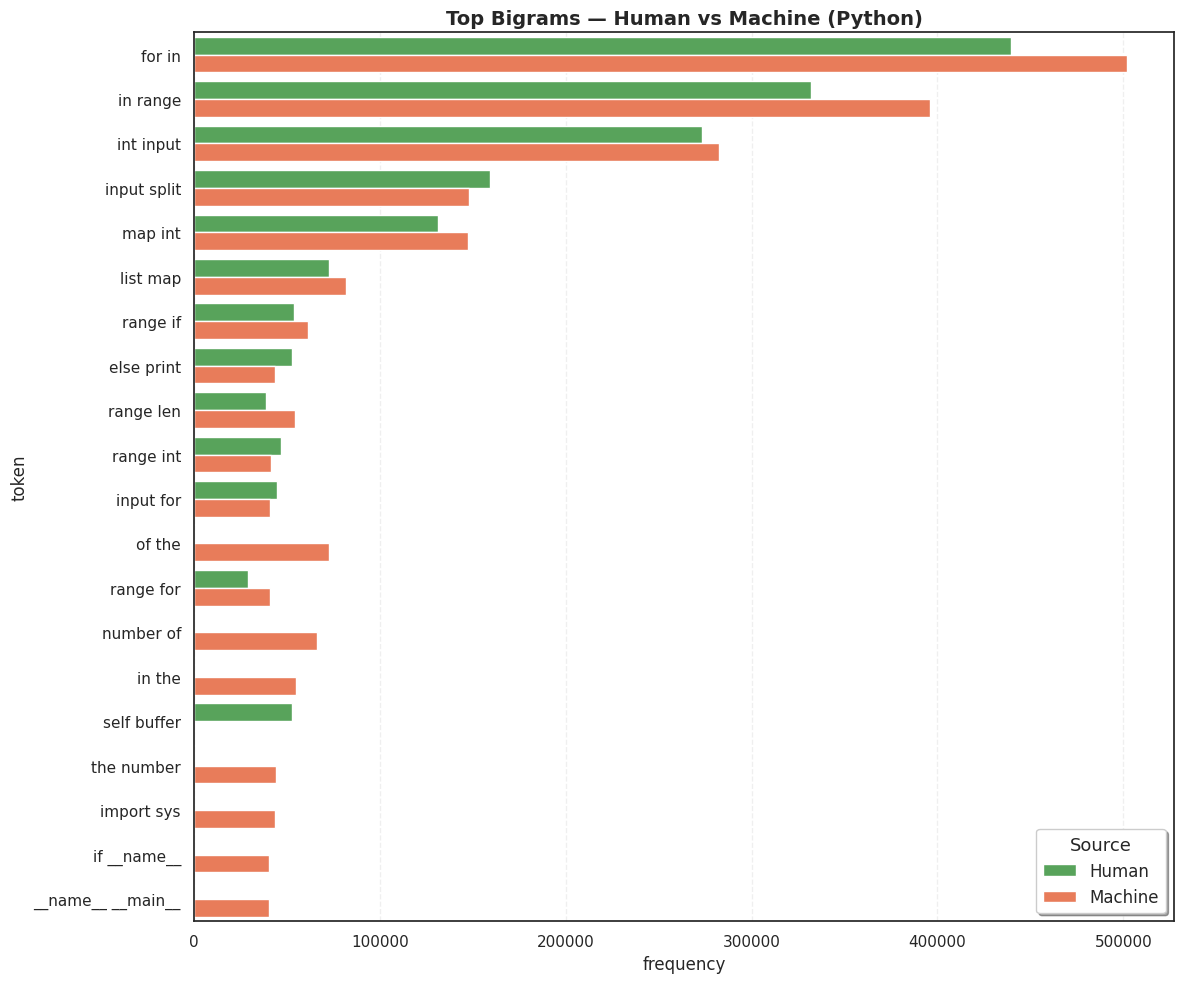

✔ Saved: plots/bigrams_by_language/bigrams_Python.pdf

=== Processing Language: Java ===


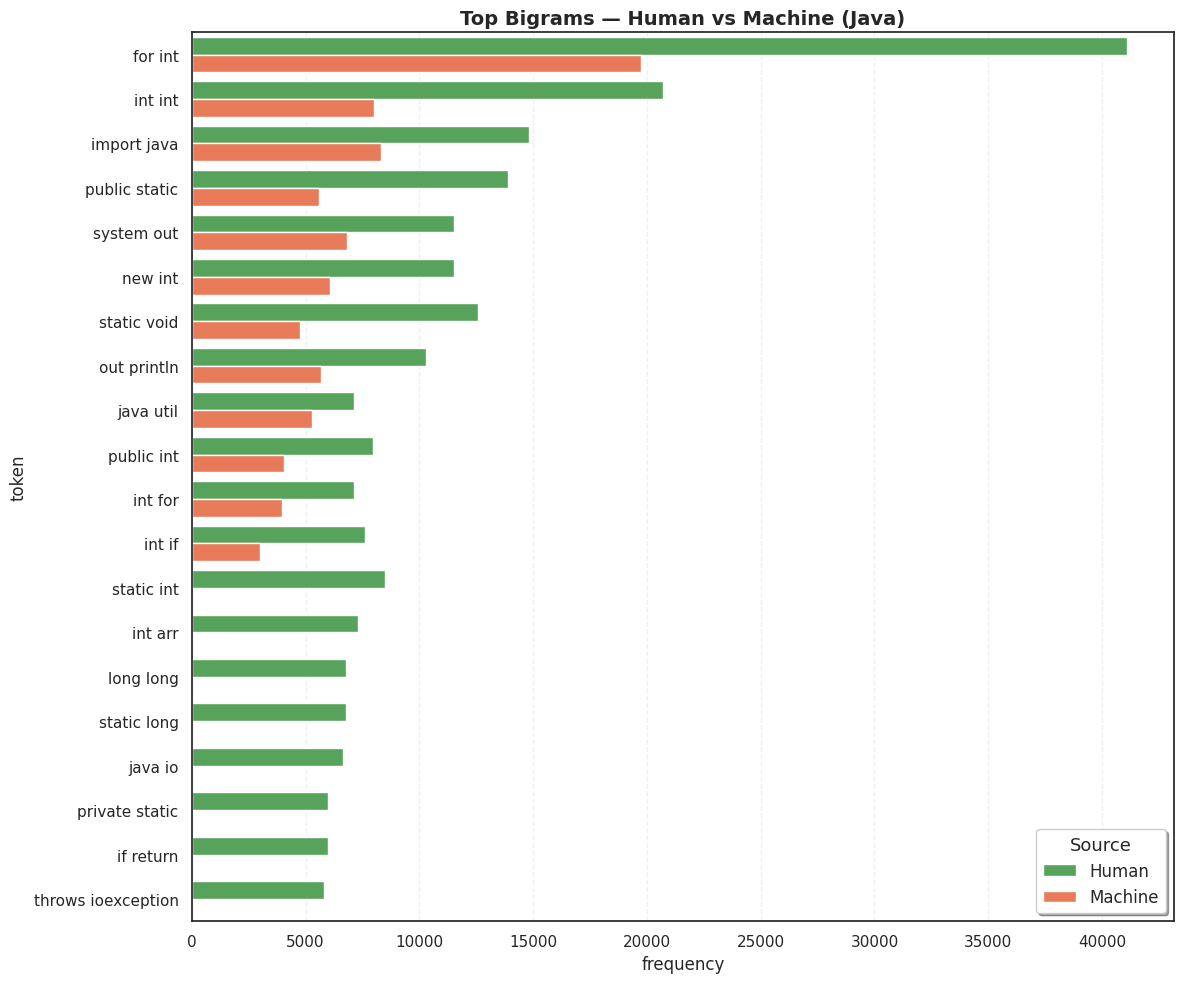

✔ Saved: plots/bigrams_by_language/bigrams_Java.pdf

=== Processing Language: C++ ===


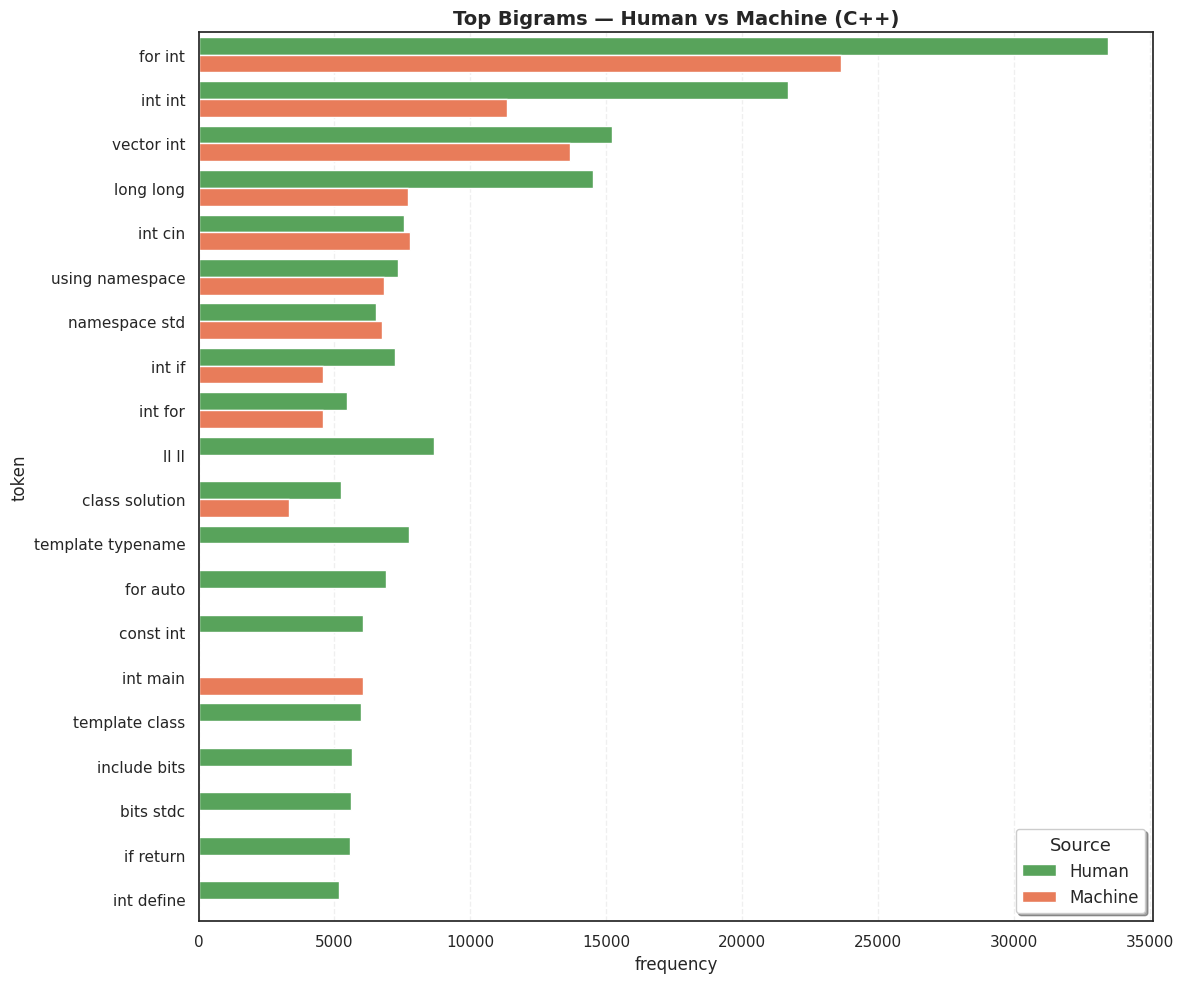

✔ Saved: plots/bigrams_by_language/bigrams_C++.pdf


In [ ]:
import os

os.makedirs("plots/bigrams_by_language", exist_ok=True)


def plot_bigrams_for_language(lang, df):
    """
    Generate Human vs Machine Bigram comparison for a single language.
    """

    lang_df = df[df["language"] == lang]

    human_code = lang_df[lang_df["generator"] == "human"]["code"]
    machine_code = lang_df[lang_df["generator"] != "human"]["code"]

    # If language has too few samples, skip
    if len(human_code) == 0 or len(machine_code) == 0:
        print(f" Skipping {lang} — missing human or machine samples.")
        return

    # --- Compute bigram frequencies ---
    human_bi_df, _ = get_token_frequencies(human_code, ngram_range=(2, 2))
    machine_bi_df, _ = get_token_frequencies(machine_code, ngram_range=(2, 2))

    TOP_N = 20

    human_top = human_bi_df.head(TOP_N).rename(columns={"frequency": "human_freq"})
    machine_top = machine_bi_df.head(TOP_N).rename(
        columns={"frequency": "machine_freq"}
    )

    merged = pd.merge(human_top, machine_top, on="token", how="outer").fillna(0)

    # Sort by combined importance
    merged["total"] = merged["human_freq"] + merged["machine_freq"]
    merged = merged.sort_values("total", ascending=False).head(TOP_N)

    if merged.empty:
        print(f" No bigrams to plot for {lang}.")
        return

    # Melt into long format
    plot_df = merged.melt(
        id_vars="token",
        value_vars=["human_freq", "machine_freq"],
        var_name="source",
        value_name="frequency",
    )

    plot_df["source"] = plot_df["source"].map(
        {"human_freq": "Human", "machine_freq": "Machine"}
    )

    # --- Plot ---
    plt.figure(figsize=(12, 10))
    sns.barplot(
        data=plot_df,
        y="token",
        x="frequency",
        hue="source",
        palette=["#4CAF50", "#FF7043"],
        dodge=True,
    )

    plt.title(f"Top Bigrams — Human vs Machine ({lang})", fontsize=14, weight="bold")

    plt.legend(
        title="Source",
        fontsize=12,
        title_fontsize=13,
        frameon=True,
        shadow=True,
    )

    plt.grid(axis="x", linestyle="--", alpha=0.3)
    plt.tight_layout()

    filename = f"plots/bigrams_by_language/bigrams_{lang}.pdf"
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

    print(f"✔ Saved: {filename}")


# --- Run for all languages ---
languages = train_data["language"].unique()

for lang in languages:
    print(f"\n=== Processing Language: {lang} ===")
    plot_bigrams_for_language(lang, train_data)

## Character-level signals (often helpful to detect AI vs human)

Compute:

- indentation style (tabs vs spaces)
- frequency of comments
- camelCase/snake_case ratios
- logical operator frequencies (if, while, for patterns)


In [ ]:
train_data["num_comments"] = train_data["code"].str.count("#|//")
train_data["num_tabs"] = train_data["code"].str.count("\t")
train_data["num_spaces"] = train_data["code"].str.count("    ")

train_data["num_lines"] = (
    train_data["code"].astype(str).apply(lambda x: x.count("\n") + 1)
)
train_data["num_defs"] = train_data["code"].astype(str).str.count(r"\bdef\b")
train_data["num_for"] = train_data["code"].astype(str).str.count(r"\bfor\b")
train_data["num_if"] = train_data["code"].astype(str).str.count(r"\bif\b")
train_data["num_import"] = train_data["code"].astype(str).str.count(r"\bimport\b")

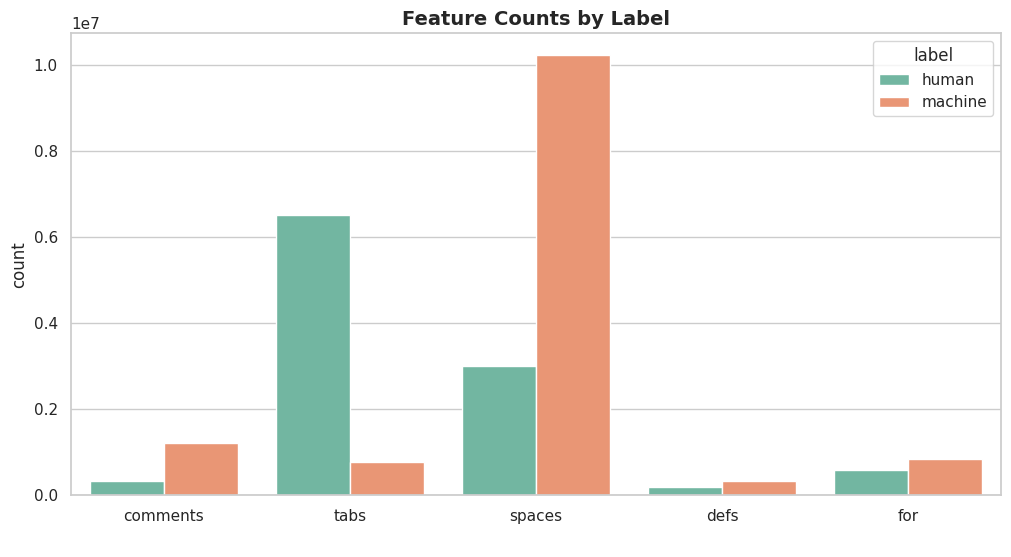

In [ ]:
# Sum counts per label
summary = train_data.groupby("label")[
    [
        "camel_count",
        "snake_count",
        "num_comments",
        "num_tabs",
        "num_spaces",
        "num_defs",
        "num_for",
    ]
].sum()

# Convert to long format
summary = summary.reset_index().melt(
    id_vars="label",
    value_vars=[
        "camel_count",
        "snake_count",
        "num_comments",
        "num_tabs",
        "num_spaces",
        "num_defs",
        "num_for",
    ],
    var_name="feature",
    value_name="count",
)

# Map old column names to clean names
name_map = {
    # "camel_count": "camel",
    # "snake_count": "snake",
    "num_comments": "comments",
    "num_tabs": "tabs",
    "num_spaces": "spaces",
    "num_defs": "defs",
    "num_for": "for",
}

summary["feature"] = summary["feature"].map(name_map)

# Rename labels only for the plot
summary["label"] = summary["label"].map({0: "human", 1: "machine"})

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(data=summary, x="feature", y="count", hue="label", palette="Set2")

plt.title("Feature Counts by Label", fontsize=14, weight="bold")
plt.xlabel(" ")
plt.savefig("plots/feature_counts_by_label.pdf", bbox_inches="tight")
plt.show()


=== Processing Language: Python ===


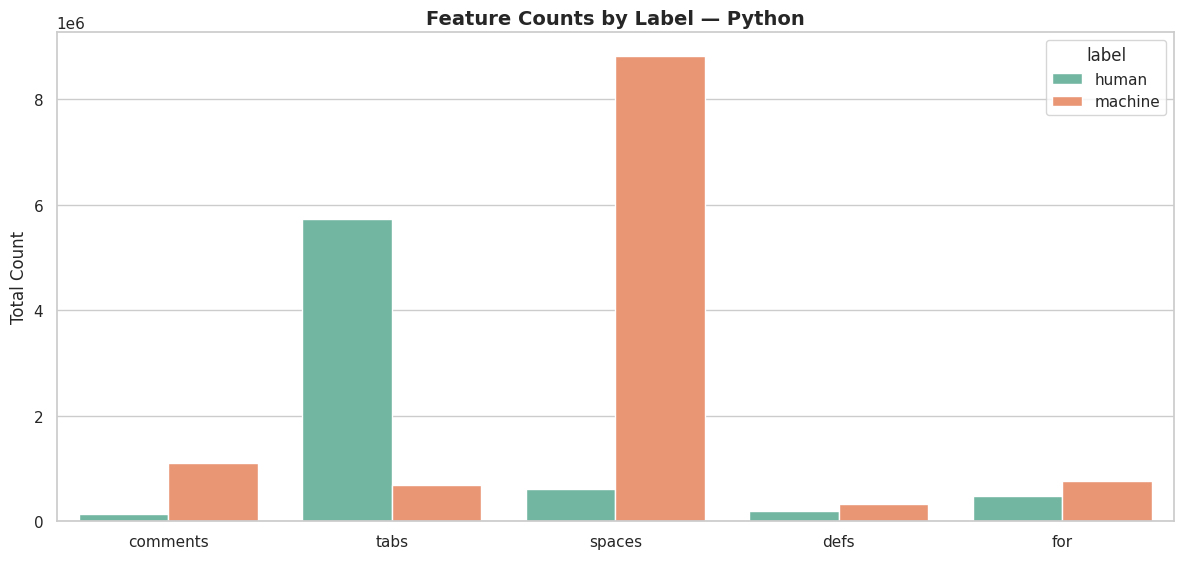

✔ Saved: plots/features_by_language/features_Python.pdf

=== Processing Language: Java ===


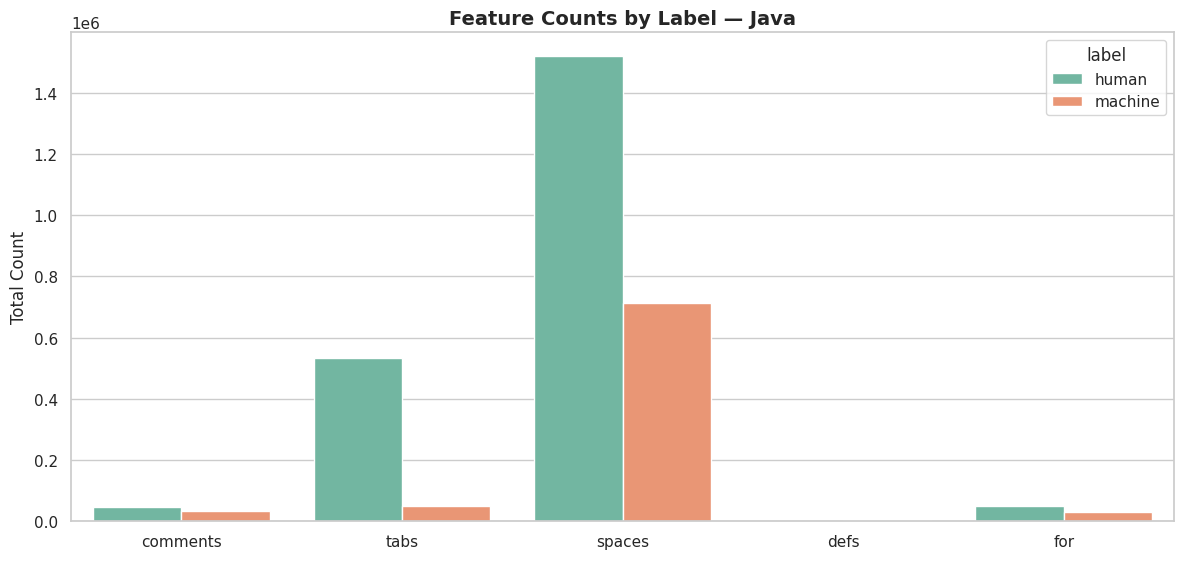

✔ Saved: plots/features_by_language/features_Java.pdf

=== Processing Language: C++ ===


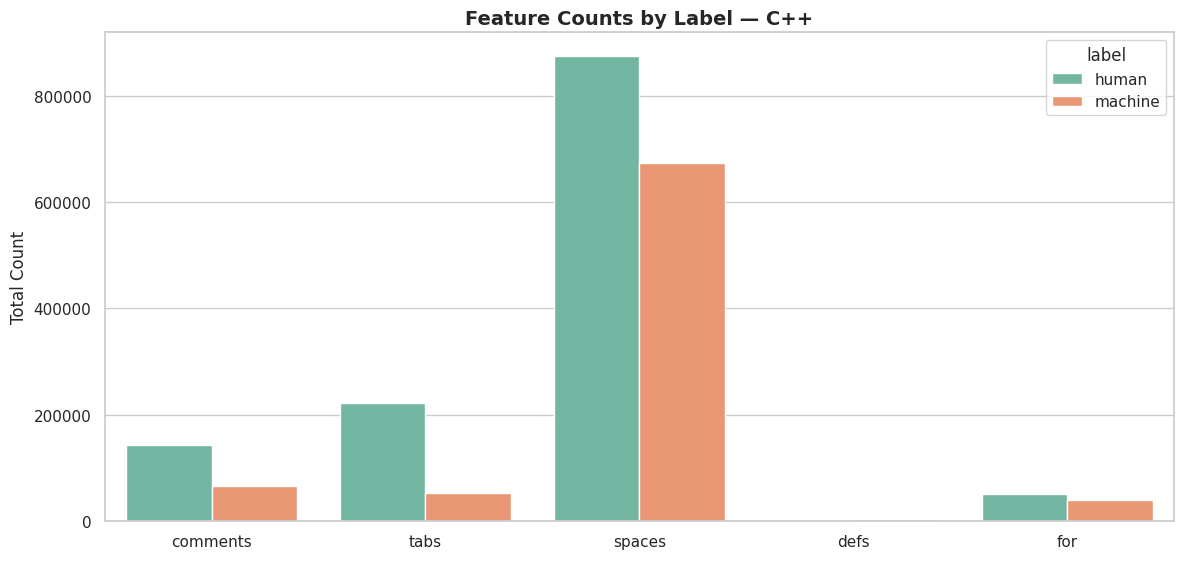

✔ Saved: plots/features_by_language/features_C++.pdf


In [ ]:
import os

os.makedirs("plots/features_by_language", exist_ok=True)

# Clean names for features
name_map = {
    # "camel_count": "camel",
    # "snake_count": "snake",
    "num_comments": "comments",
    "num_tabs": "tabs",
    "num_spaces": "spaces",
    "num_defs": "defs",
    "num_for": "for",
}

features = list(name_map.keys())


def plot_features_for_language(lang, df):
    """
    Creates a Feature Comparison Plot (Human vs Machine)
    for a single language.
    """

    lang_df = df[df["language"] == lang]

    if lang_df.empty:
        print(f" No samples for language {lang}.")
        return

    # --- Summarize ---
    summary = (
        lang_df.groupby("label")[features]
        .sum()
        .reset_index()
        .melt(
            id_vars="label", value_vars=features, var_name="feature", value_name="count"
        )
    )

    # Map feature names to readable names
    summary["feature"] = summary["feature"].map(name_map)

    # 0,1 → human, machine
    summary["label"] = summary["label"].map({0: "human", 1: "machine"})

    # --- Plot ---
    plt.figure(figsize=(12, 6))
    sns.barplot(data=summary, x="feature", y="count", hue="label", palette="Set2")

    plt.title(f"Feature Counts by Label — {lang}", fontsize=14, weight="bold")
    plt.ylabel("Total Count")
    plt.xlabel(" ")

    plt.tight_layout()

    # Save
    filename = f"plots/features_by_language/features_{lang}.pdf"
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

    print(f"✔ Saved: {filename}")


# ---- RUN FOR ALL LANGUAGES ----
languages = train_data["language"].unique()

for lang in languages:
    print(f"\n=== Processing Language: {lang} ===")
    plot_features_for_language(lang, train_data)

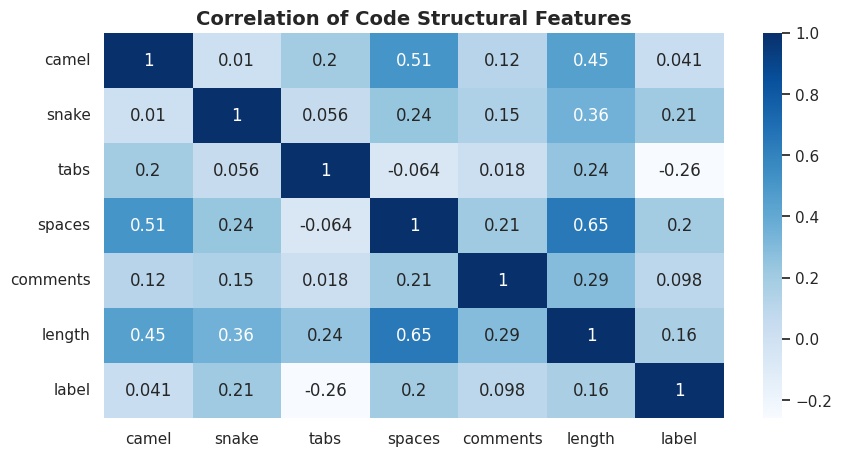

In [ ]:
# Heatmap of Structural Features
# Select features
features = [
    "camel_count",
    "snake_count",
    "num_tabs",
    "num_spaces",
    "num_comments",
    "code_length",
    "label",
]

# Compute correlation
corr_matrix = train_data[features].corr()

# Map old column names to clean names
name_map = {
    "camel_count": "camel",
    "snake_count": "snake",
    "num_tabs": "tabs",
    "num_spaces": "spaces",
    "num_comments": "comments",
    "code_length": "length",
    "label": "label",
}

# Rename rows and columns
corr_matrix.rename(index=name_map, columns=name_map, inplace=True)

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap="Blues")
plt.title("Correlation of Code Structural Features", fontsize=14, weight="bold")
plt.savefig("plots/correlation_of_code_structural_features.pdf", bbox_inches="tight")
plt.show()

## Duplicates


In [ ]:
total_dupes = train_data.duplicated("code").sum()
dupes = train_data[train_data.duplicated("code", keep=False)]
total_dupes, dupes.head()

(np.int64(0),
 Empty DataFrame
 Columns: [code, generator, label, language, code_length, camel_count, snake_count, total_idents, camel_ratio, snake_ratio, num_comments, num_tabs, num_spaces, num_lines, num_defs, num_for, num_if, num_import]
 Index: [])

## Advanced: Code Complexity Score

Insight:


In [ ]:
def complexity_score(text):
    score = 0
    score += text.count("for")
    score += text.count("while")
    score += text.count("if")
    score += text.count("elif")
    score += text.count("class")
    score += text.count("def")
    return score


train_data["complexity"] = (
    train_data[train_data["code_length"] < train_data["code_length"].quantile(0.90)][
        "code"
    ]
    .astype(str)
    .apply(complexity_score)
)

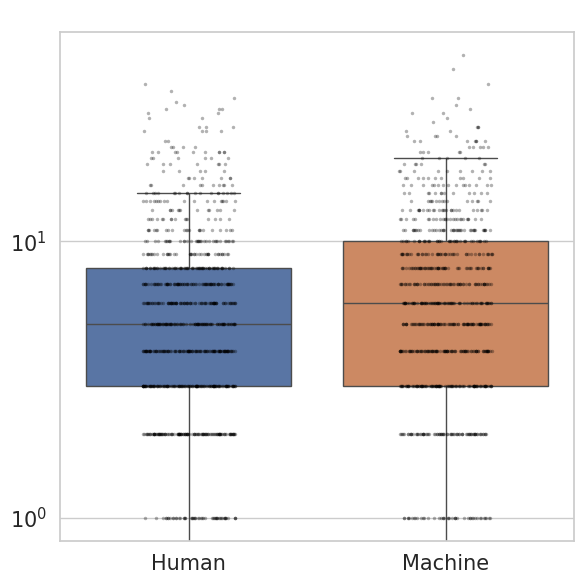

In [ ]:
# ---------------------------------------
# Filter data properly
# ---------------------------------------
filtered = train_data[
    train_data["code_length"] < train_data["code_length"].quantile(0.90)
].copy()

filtered["complexity"] = filtered["code"].astype(str).apply(complexity_score)
filtered["label"] = filtered["label"].map({0: "Human", 1: "Machine"})
filtered = filtered[filtered["complexity"] <= 150]

# ---------------------------------------
# Plot
# ---------------------------------------
plt.figure(figsize=(6, 6))

sns.boxplot(
    data=filtered,
    x="label",
    y="complexity",
    width=0.8,
    showfliers=False,
    hue="label",
)

sns.stripplot(
    data=filtered.sample(min(2000, len(filtered))),  # avoid overplotting
    x="label",
    y="complexity",
    alpha=0.3,
    size=2.5,
    color="black",
    jitter=0.18,
)

plt.yscale("log")  # Helps with skewed distributions
plt.ylabel("")
plt.xlabel("")
plt.title(" ")
ax = plt.gca()
ax.tick_params(axis="both", labelsize=15)
plt.tight_layout()
plt.savefig("plots/complexity_score.pdf", format="pdf", dpi=300)
plt.show()

## WordCloud: Human And Machine


Text(0.5, 1.0, 'Human Code WordCloud')

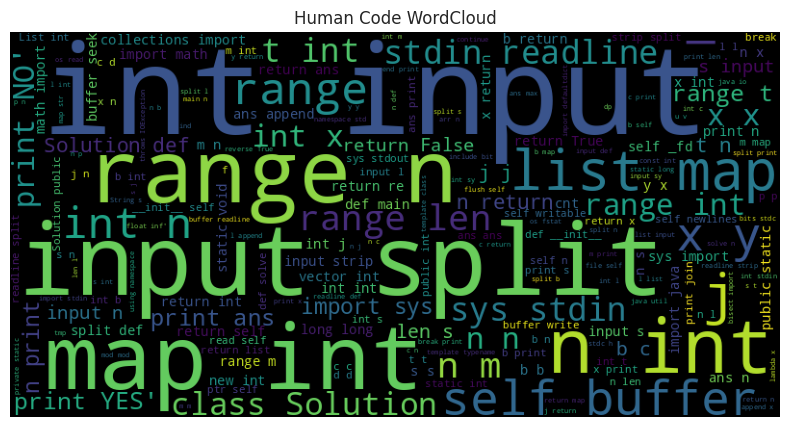

In [ ]:
# Human-written code

from wordcloud import WordCloud

wc_human = WordCloud(width=800, height=400).generate(
    " ".join(train_data[train_data.label == 0].code.astype(str))
)
plt.imshow(wc_human)
plt.axis("off")
plt.title("Human Code WordCloud")

Text(0.5, 1.0, 'Machine Code WordCloud')

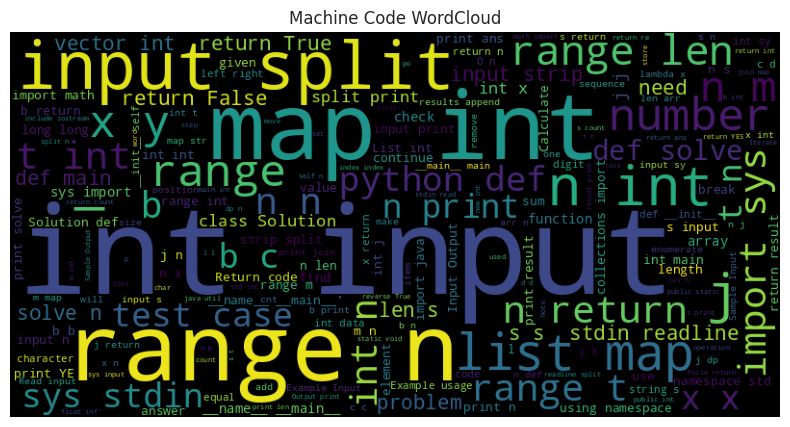

In [ ]:
# Machine-generated code
wc_llm = WordCloud(width=800, height=400).generate(
    " ".join(train_data[train_data.label == 1].code.astype(str))
)
plt.imshow(wc_llm)
plt.axis("off")
plt.title("Machine Code WordCloud")

In [40]:
train_data["loop_density"].shape

(500000,)

In [62]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", font_scale=0.95)


def thousands_formatter(x, pos):
    if x == 0:
        return "0"
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    if x >= 1_000:
        return f"{int(x/1000)}K"
    return f"{int(x)}"


def plot_feature_group(
    df, feature_cols, group_title, filename, agg="sum", y_limit=None, y_fmt="thousands"
):
    """
    Reusable catplot builder matching your camelCase/snake_case style.

    Parameters
    ----------
    df         : train_data
    feature_cols : list of column names to compare
    group_title  : suptitle string
    filename     : save path (PDF)
    agg          : "sum" or "mean"
    y_limit      : (0, max_val) tuple or None for auto
    y_fmt        : "thousands" | "decimal" | "percent"
    """

    # ── 1. Aggregate ────────────────────────────────────────────────────────
    agg_fn = "sum" if agg == "sum" else "mean"
    summary = df.groupby(["language", "label"])[feature_cols].agg(agg_fn).reset_index()

    # ── 2. Wide → long ───────────────────────────────────────────────────────
    summary = summary.melt(
        id_vars=["language", "label"],
        value_vars=feature_cols,
        var_name="feature",
        value_name="value",
    )
    summary["label"] = summary["label"].map({0: "human", 1: "machine"})

    # ── 3. Plot ───────────────────────────────────────────────────────────────
    n_cols = min(len(feature_cols), 4)  # max 4 per row
    n_rows = (len(feature_cols) + n_cols - 1) // n_cols

    g = sns.catplot(
        data=summary,
        x="language",
        y="value",
        hue="label",
        col="feature",
        col_wrap=n_cols,
        kind="bar",
        height=4.5,
        aspect=1.1,
        palette="Set2",
        errorbar=None,
        sharey=False,
        legend=True,
    )

    # ── 4. Y-axis formatting ──────────────────────────────────────────────────
    fmt_map = {
        "thousands": ticker.FuncFormatter(thousands_formatter),
        "decimal": ticker.FuncFormatter(lambda x, _: f"{x:.2f}"),
        "percent": ticker.FuncFormatter(lambda x, _: f"{x:.0%}"),
    }
    for ax in g.axes.flat:
        ax.yaxis.set_major_formatter(fmt_map.get(y_fmt, fmt_map["thousands"]))
        if y_limit:
            ax.set_ylim(*y_limit)
        ax.tick_params(axis="x", rotation=45, labelsize=8)

    # ── 5. Clean labels & sub-titles ─────────────────────────────────────────
    g._legend.remove()
    g.set_titles(" ")
    g.set_axis_labels(" ", " ")

    feature_names = summary["feature"].unique()
    for ax, feat in zip(g.axes.flat, feature_names):
        label = feat.replace("_", " ")  # e.g. "num nested loops"
        ax.text(
            0.5,
            -0.22,
            label,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=10,
            weight="bold",
        )

    # ── 6. Shared legend ──────────────────────────────────────────────────────
    handles, labels = g.axes.flat[0].get_legend_handles_labels()
    g.fig.legend(
        handles,
        labels,
        title=False,
        loc="upper right",
        bbox_to_anchor=(0.98, 1.0),
        frameon=True,
        fontsize=9,
    )

    g.fig.suptitle(group_title, y=1.04, fontsize=13, weight="bold")
    sns.despine()
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.savefig(filename, format="pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved → {filename}")

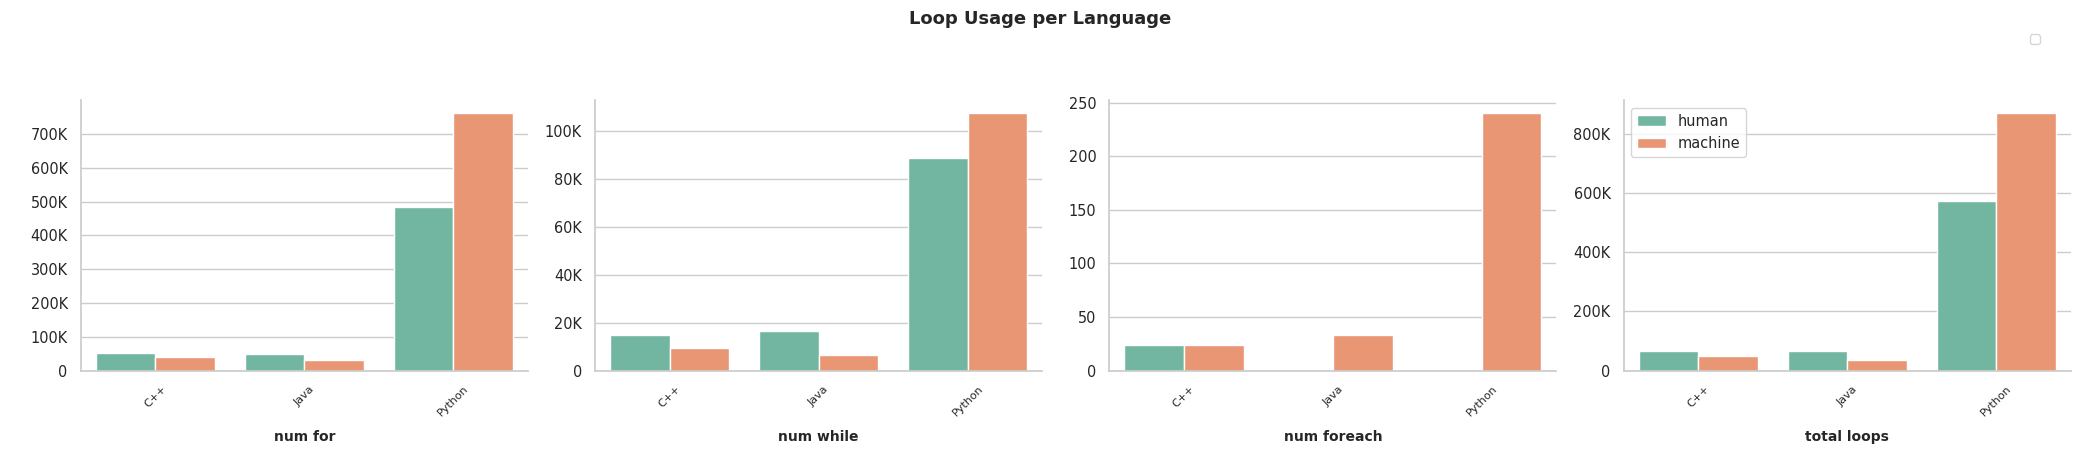

Saved → plots/loop_counts.pdf


In [63]:
plot_feature_group(
    train_data,
    feature_cols=["num_for", "num_while", "num_foreach", "total_loops"],
    group_title="Loop Usage per Language",
    filename="plots/loop_counts.pdf",
    agg="sum",
    y_fmt="thousands",
)

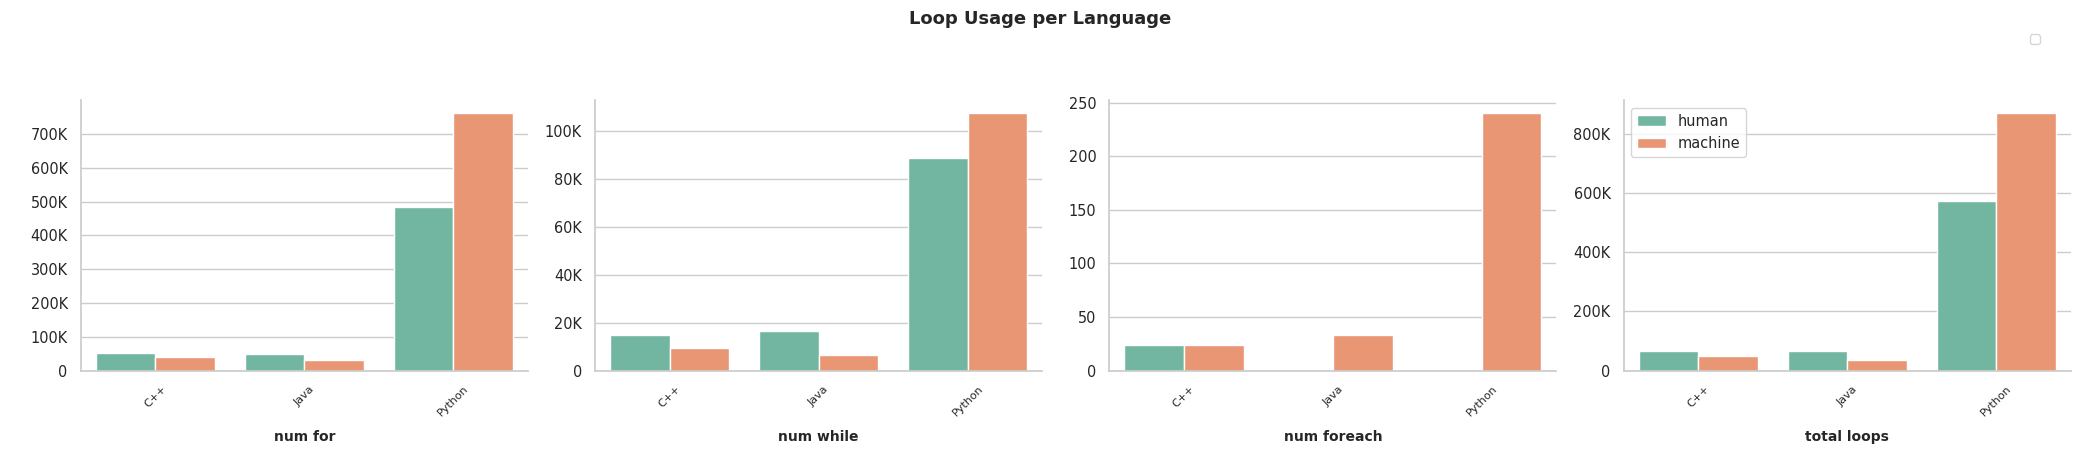

Saved → plots/loop_counts.pdf


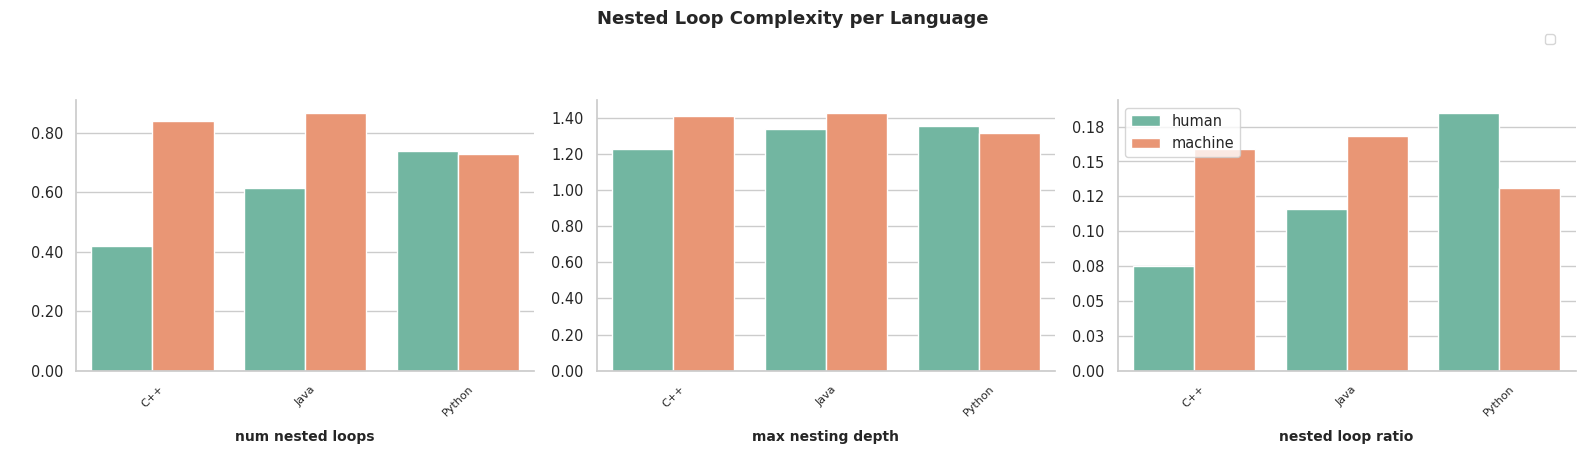

Saved → plots/nested_loops.pdf


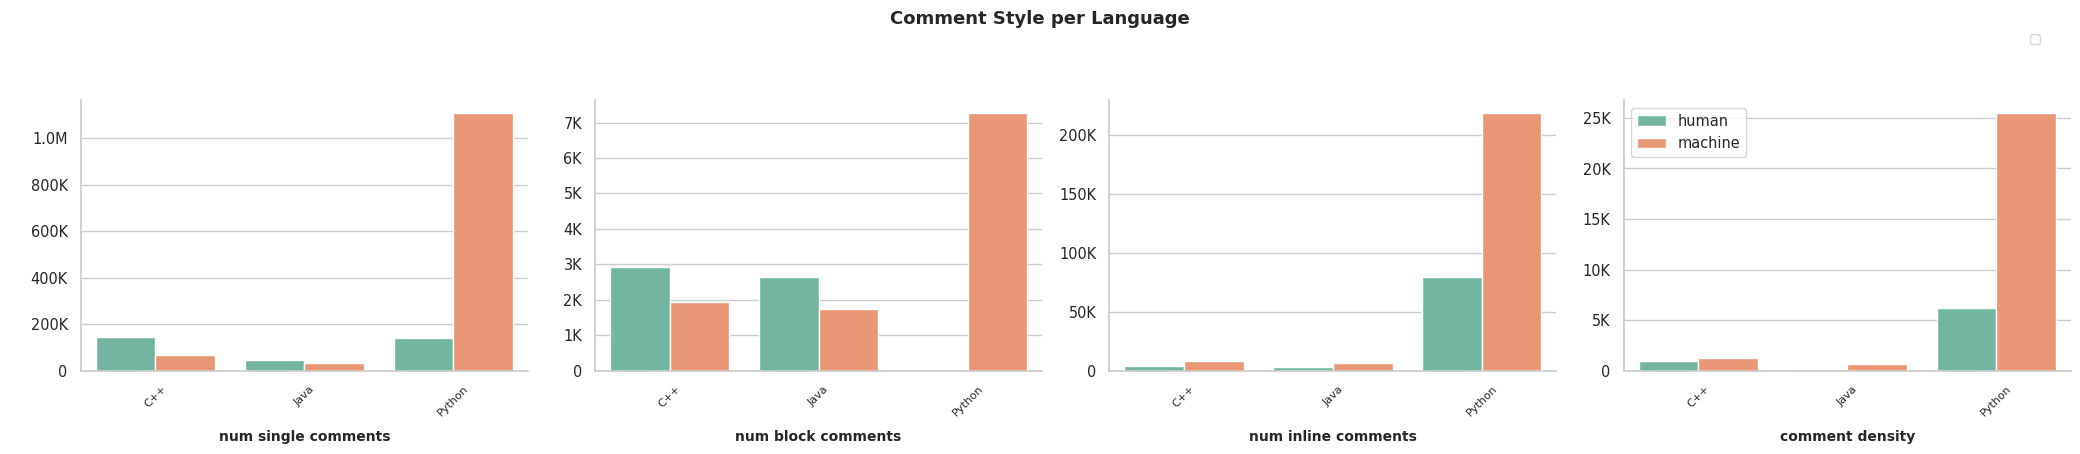

Saved → plots/comments.pdf


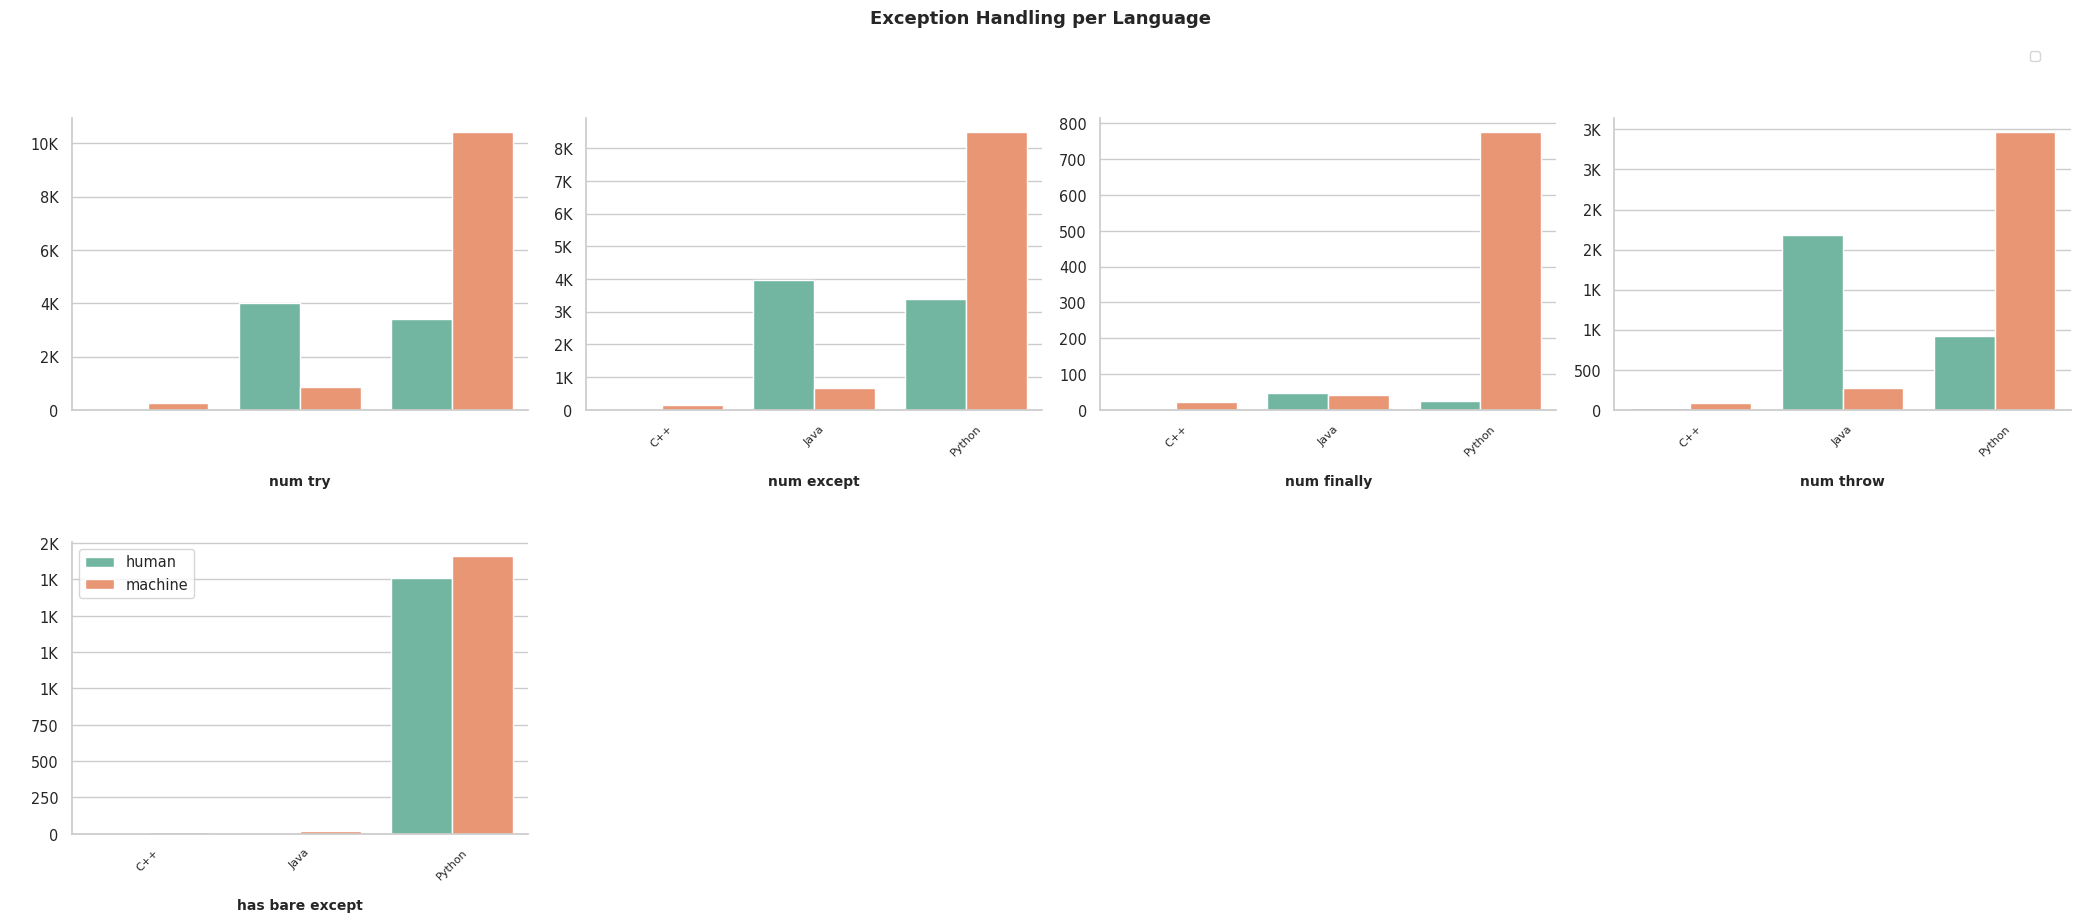

Saved → plots/exceptions.pdf


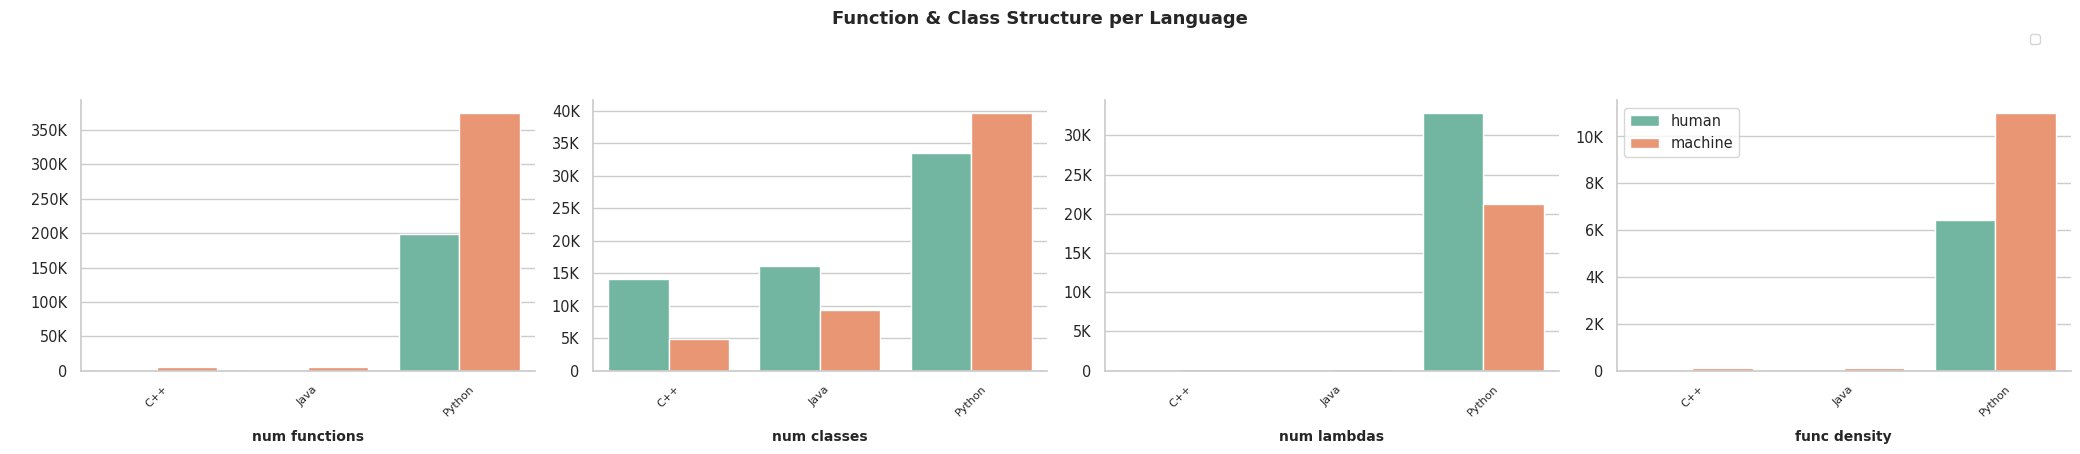

Saved → plots/functions.pdf


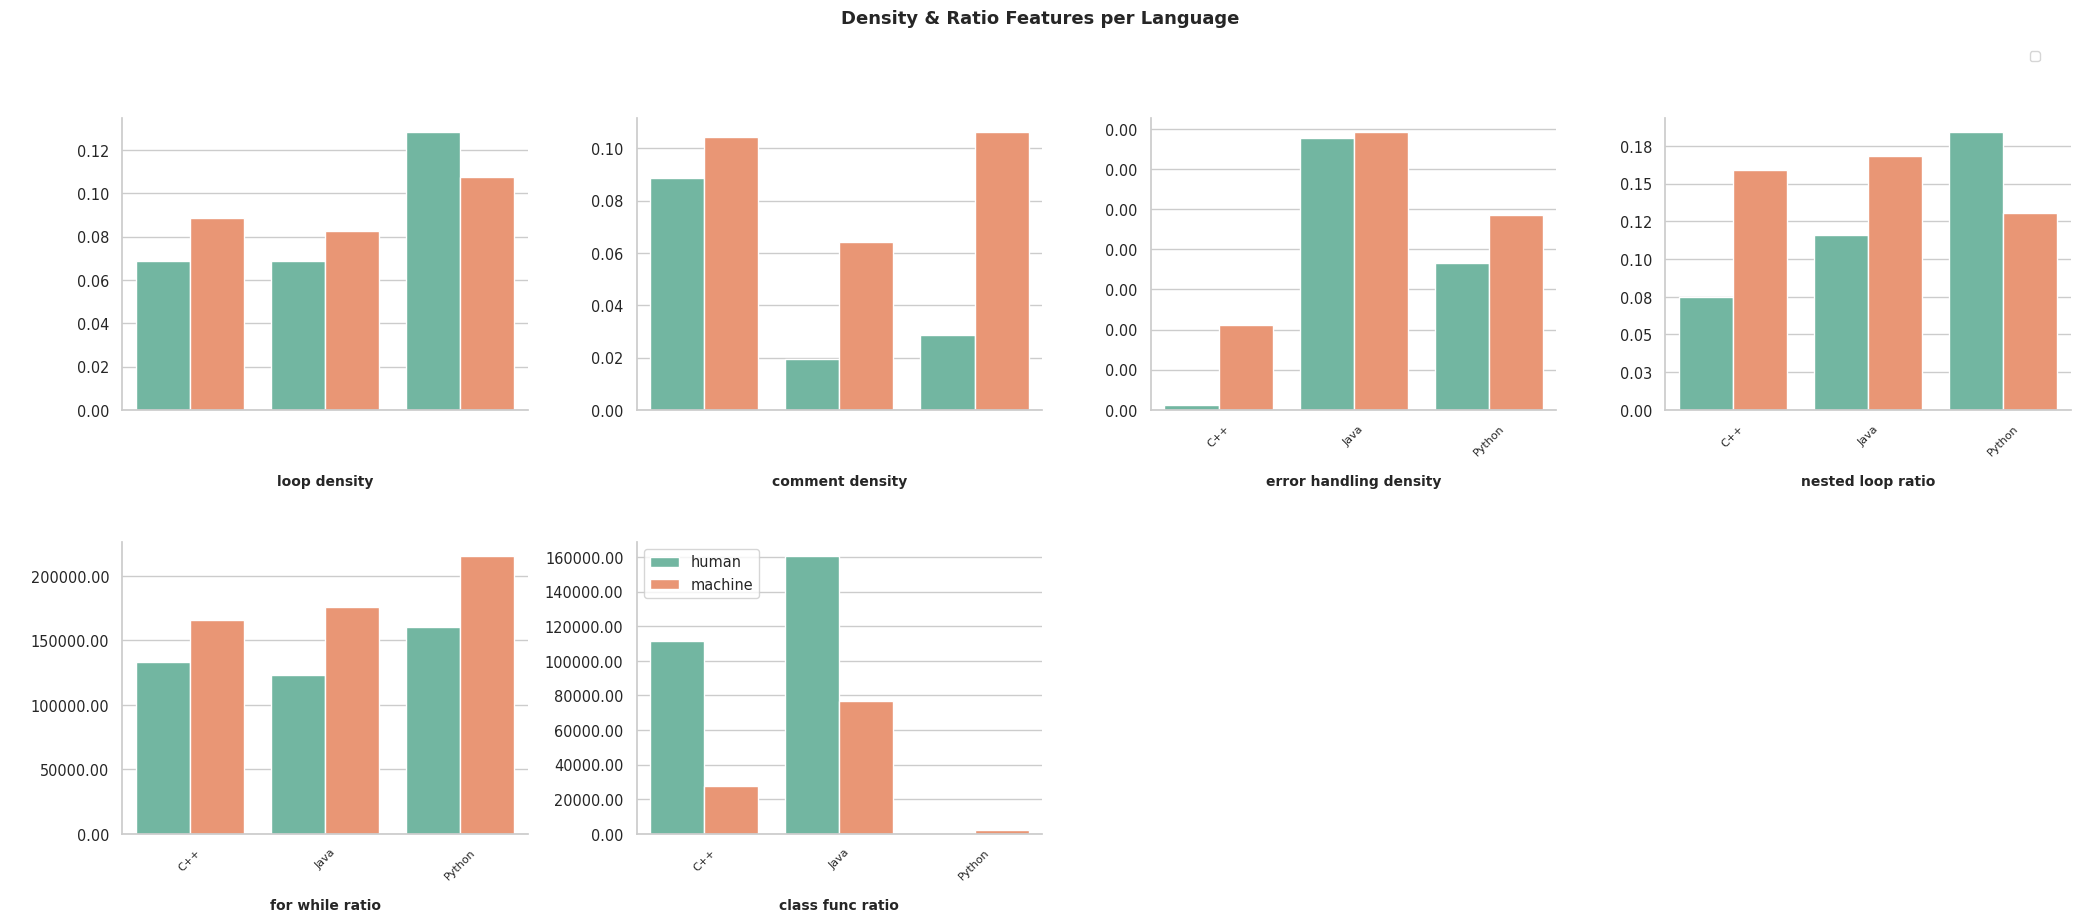

Saved → plots/densities.pdf


In [64]:
# ════════════════════════════════════════════════════════════════════════════
# CALL ONCE PER FEATURE GROUP
# ════════════════════════════════════════════════════════════════════════════

# 1. Loop counts
plot_feature_group(
    train_data,
    feature_cols=["num_for", "num_while", "num_foreach", "total_loops"],
    group_title="Loop Usage per Language",
    filename="plots/loop_counts.pdf",
    agg="sum",
    y_fmt="thousands",
)

# 2. Nested loops  (use mean — sum would just reflect dataset size)
plot_feature_group(
    train_data,
    feature_cols=["num_nested_loops", "max_nesting_depth", "nested_loop_ratio"],
    group_title="Nested Loop Complexity per Language",
    filename="plots/nested_loops.pdf",
    agg="mean",
    y_fmt="decimal",
)

# 3. Comment features
plot_feature_group(
    train_data,
    feature_cols=[
        "num_single_comments",
        "num_block_comments",
        "num_inline_comments",
        "comment_density",
    ],
    group_title="Comment Style per Language",
    filename="plots/comments.pdf",
    agg="sum",
    y_fmt="thousands",
)

# 4. Exception handling
plot_feature_group(
    train_data,
    feature_cols=[
        "num_try",
        "num_except",
        "num_finally",
        "num_throw",
        "has_bare_except",
    ],
    group_title="Exception Handling per Language",
    filename="plots/exceptions.pdf",
    agg="sum",
    y_fmt="thousands",
)

# 5. Function & class structure
plot_feature_group(
    train_data,
    feature_cols=["num_functions", "num_classes", "num_lambdas", "func_density"],
    group_title="Function & Class Structure per Language",
    filename="plots/functions.pdf",
    agg="sum",
    y_fmt="thousands",
)

# 6. Density / ratio features  (mean makes more sense than sum here)
plot_feature_group(
    train_data,
    feature_cols=[
        "loop_density",
        "comment_density",
        "error_handling_density",
        "nested_loop_ratio",
        "for_while_ratio",
        "class_func_ratio",
    ],
    group_title="Density & Ratio Features per Language",
    filename="plots/densities.pdf",
    agg="mean",
    y_fmt="decimal",
)